In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# --- PFAD-CHECK ---
# Wir nutzen den absoluten Pfad, den du am Anfang genannt hast
file_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy/data_csv/final_Data_iaaf_scores_neu.csv'

if not os.path.exists(file_path):
    print(f"❌ DATEI NICHT GEFUNDEN!")
    print(f"Gesuchter Pfad: {file_path}")
    print(f"Aktuelles Arbeitsverzeichnis: {os.getcwd()}")
else:
    print(f"✅ Datei gefunden! Lade Daten...")
    
    # 1. Daten laden mit Fehlerbehandlung
    try:
        # Versuche Semikolon (Standard bei deutschen CSVs)
        df = pd.read_csv(file_path, sep=';')
        # Falls die Datei nur eine Spalte hat, war das Trennzeichen falsch
        if df.shape[1] <= 1:
            df = pd.read_csv(file_path, sep=',')
            
        print(f"Erfolgreich geladen: {df.shape[0]} Zeilen und {df.shape[1]} Spalten.")

        # --- AB HIER DEINE ANALYSE ---

        # 2. Kategorisierung
        def categorize_with_100m(d):
            d = str(d).lower()
            if '100 m' in d and 'huerden' not in d:
                return '100m Sprint'
            if any(x in d for x in ['sprung']):
                return 'Jumping'
            if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']):
                return 'Throwing'
            if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']):
                return 'Other Track'
            return 'Combined Events'

        df['category'] = df['disziplin'].apply(categorize_with_100m)

        # 3. Top 30 Berechnung (ab 2015)
        df_recent = df[df['jahr'] >= 2015].copy()

        def get_top_30_mean(group):
            return group.nlargest(30, 'iaaf_score')['iaaf_score'].mean()

        # Schritt A: Top 30 pro Disziplin
        top_30_stats = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin']).apply(get_top_30_mean).reset_index(name='iaaf_score')

        # Schritt B & C: Aggregation
        category_stats = top_30_stats.groupby(['jahr', 'category'])['iaaf_score'].mean().reset_index()
        total_stats = top_30_stats.groupby(['jahr'])['iaaf_score'].mean().reset_index()
        total_stats['category'] = 'GESAMT (Alle Disziplinen)'

        final_stats = pd.concat([category_stats, total_stats], ignore_index=True)

        # 4. Prozentuale Änderung (Basis 2015)
        def calculate_pct_change(group):
            base_val = group.loc[group['jahr'] == 2015, 'iaaf_score']
            if not base_val.empty:
                b = base_val.values[0]
                group['rel_change_pct'] = ((group['iaaf_score'] - b) / b) * 100
            else:
                group['rel_change_pct'] = 0
            return group

        final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

        # 5. Visualisierung
        colors = {
            '100m Sprint': '#D4A017', 'Jumping': '#4A90C0', 'Throwing': '#8B0000',
            'Other Track': '#6DBED8', 'Combined Events': '#8B6914', 'GESAMT (Alle Disziplinen)': '#2F4F4F'
        }

        fig, ax = plt.subplots(figsize=(12, 7))
        for cat in sorted(final_stats['category'].unique()):
            cat_data = final_stats[final_stats['category'] == cat].sort_values('jahr')
            lw, z, marker = (3, 10, 's') if 'GESAMT' in cat else (2, 5, 'o')
            ax.plot(cat_data['jahr'], cat_data['rel_change_pct'], label=cat, 
                    color=colors.get(cat, 'gray'), linewidth=lw, zorder=z, marker=marker)

        ax.axhline(0, color='black', linewidth=1, alpha=0.3)
        ax.axvspan(2020, 2021, color='red', alpha=0.1, label='COVID-19 Impact')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_title('Leistungsentwicklung seit 2015 (Top 30 Schnitt)', fontsize=14)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Ein Fehler ist aufgetreten: {e}")

RecursionError: maximum recursion depth exceeded

/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/4024846487.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_30_std = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin']).apply(get_top_30_std).reset_index(name='sd_score')
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/4024846487.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_sd_stats = 

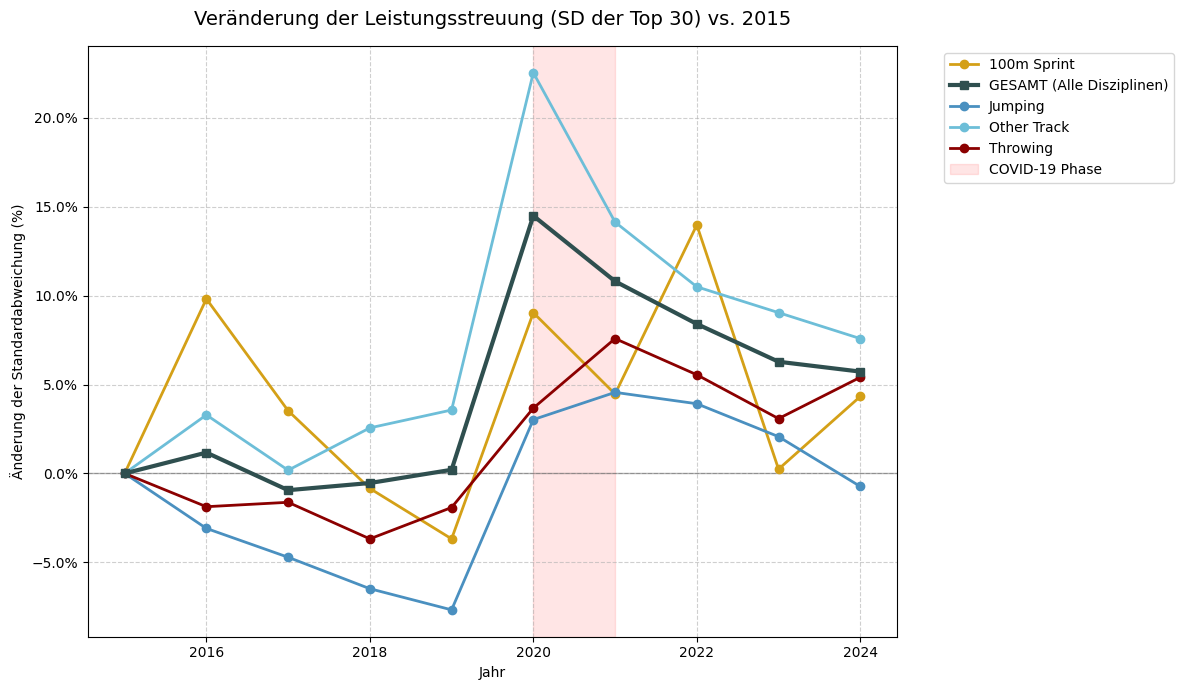

Analyse der Standardabweichung abgeschlossen.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# Pfad zu deiner Datei
file_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy/data_csv/final_Data_iaaf_scores_neu.csv'

if not os.path.exists(file_path):
    print(f"❌ DATEI NICHT GEFUNDEN unter: {file_path}")
else:
    # 1. Daten laden
    try:
        df = pd.read_csv(file_path, sep=';')
        if df.shape[1] <= 1:
            df = pd.read_csv(file_path, sep=',')
            
        # 2. Kategorisierung
        def categorize(d):
            d = str(d).lower()
            if '100 m' in d and 'huerden' not in d: return '100m Sprint'
            if 'sprung' in d: return 'Jumping'
            if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
            if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
            return 'Combined Events'

        df['category'] = df['disziplin'].apply(categorize)
        df_recent = df[df['jahr'] >= 2015].copy()

        # 3. Standardabweichung der Top 30 berechnen
        def get_top_30_std(group):
            # Wir nehmen die Top 30 Scores und berechnen deren Standardabweichung
            return group.nlargest(30, 'iaaf_score')['iaaf_score'].std()

        # SD pro Disziplin berechnen
        top_30_std = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin']).apply(get_top_30_std).reset_index(name='sd_score')

        # Aggregation auf Kategorien-Ebene (Mittelwert der Standardabweichungen)
        category_sd = top_30_std.groupby(['jahr', 'category'])['sd_score'].mean().reset_index()
        
        # Gesamt-Durchschnitt der SD
        total_sd = top_30_std.groupby(['jahr'])['sd_score'].mean().reset_index()
        total_sd['category'] = 'GESAMT (Alle Disziplinen)'

        final_sd_stats = pd.concat([category_sd, total_sd], ignore_index=True)

        # 4. Prozentuale Änderung der SD (Basisjahr 2015)
        def calculate_pct_change(group):
            base_val = group.loc[group['jahr'] == 2015, 'sd_score']
            if not base_val.empty and base_val.values[0] != 0:
                b = base_val.values[0]
                group['sd_rel_change_pct'] = ((group['sd_score'] - b) / b) * 100
            else:
                group['sd_rel_change_pct'] = 0
            return group

        final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

        # 5. Visualisierung
        colors = {
            '100m Sprint': '#D4A017', 'Jumping': '#4A90C0', 'Throwing': '#8B0000',
            'Other Track': '#6DBED8', 'Combined Events': '#8B6914', 'GESAMT (Alle Disziplinen)': '#2F4F4F'
        }

        fig, ax = plt.subplots(figsize=(12, 7))
        
        for cat in sorted(final_sd_stats['category'].unique()):
            cat_data = final_sd_stats[final_sd_stats['category'] == cat].sort_values('jahr')
            lw, z, marker = (3, 10, 's') if 'GESAMT' in cat else (2, 5, 'o')
            
            ax.plot(cat_data['jahr'], cat_data['sd_rel_change_pct'], 
                    label=cat, color=colors.get(cat, 'gray'), 
                    linewidth=lw, zorder=z, marker=marker)

        # Layout & Labels
        ax.axhline(0, color='black', linewidth=1, alpha=0.3)
        ax.axvspan(2020, 2021, color='red', alpha=0.1, label='COVID-19 Phase')
        
        ax.set_title('Veränderung der Leistungsstreuung (SD der Top 30) vs. 2015', fontsize=14, pad=15)
        ax.set_ylabel('Änderung der Standardabweichung (%)')
        ax.set_xlabel('Jahr')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.grid(True, linestyle='--', alpha=0.6)
        
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

        print("Analyse der Standardabweichung abgeschlossen.")

    except Exception as e:
        print(f"❌ Fehler: {e}")

/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/145510149.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datum'] = pd.to_datetime(df['datum'], errors='coerce')


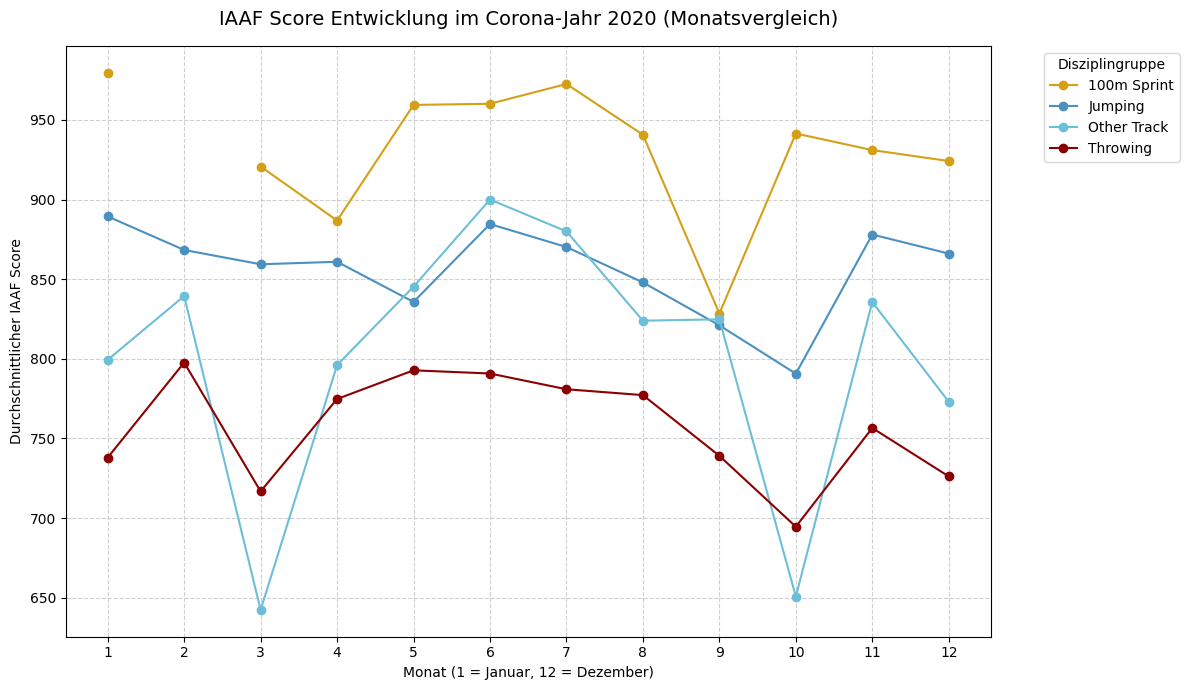

Analyse für 2020 abgeschlossen.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# Pfad zu deiner Datei
file_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy/data_csv/final_Data_iaaf_scores_neu.csv'

if not os.path.exists(file_path):
    print(f"❌ DATEI NICHT GEFUNDEN: {file_path}")
else:
    try:
        # 1. Daten laden
        df = pd.read_csv(file_path, sep=';')
        if df.shape[1] <= 1:
            df = pd.read_csv(file_path, sep=',')

        # 2. Datum konvertieren und Monat extrahieren
        # Ich nehme an, die Spalte heißt 'datum'. Falls sie anders heißt, bitte hier anpassen:
        if 'datum' in df.columns:
            df['datum'] = pd.to_datetime(df['datum'], errors='coerce')
            df['monat'] = df['datum'].dt.month
        else:
            # Falls kein Datum vorhanden ist, sondern nur Monate als Zahlen (1-12)
            # Hier müsste man wissen, wie die Zeitinfo im Datensatz gespeichert ist.
            print("⚠️ Warnung: Keine Spalte 'datum' gefunden. Versuche alternative Spalte...")
            # Beispiel-Fallback, falls die Spalte 'monat' bereits existiert:
            if 'monat' not in df.columns:
                 raise KeyError("Die Datei benötigt eine Spalte 'datum' oder 'monat' für diese Analyse.")

        # 3. Filter auf das Jahr 2020
        df_2020 = df[df['jahr'] == 2020].copy()
        
        if df_2020.empty:
            print("❌ Keine Daten für das Jahr 2020 gefunden!")
        else:
            # 4. Kategorisierung (wie zuvor)
            def categorize(d):
                d = str(d).lower()
                if '100 m' in d and 'huerden' not in d: return '100m Sprint'
                if 'sprung' in d: return 'Jumping'
                if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
                if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
                return 'Combined Events'

            df_2020['category'] = df_2020['disziplin'].apply(categorize)

            # 5. Durchschnittlicher IAAF Score pro Monat und Kategorie
            # Wir nehmen den Mittelwert der Top-Leistungen pro Monat
            monthly_stats = df_2020.groupby(['monat', 'category'])['iaaf_score'].mean().unstack()

            # 6. Visualisierung
            fig, ax = plt.subplots(figsize=(12, 7))
            
            # Farben wie zuvor
            colors = {
                '100m Sprint': '#D4A017', 'Jumping': '#4A90C0', 'Throwing': '#8B0000',
                'Other Track': '#6DBED8', 'Combined Events': '#8B6914'
            }

            monthly_stats.plot(kind='line', marker='o', ax=ax, color=[colors.get(c, 'gray') for c in monthly_stats.columns])

            # Styling
            ax.set_title('IAAF Score Entwicklung im Corona-Jahr 2020 (Monatsvergleich)', fontsize=14, pad=15)
            ax.set_xlabel('Monat (1 = Januar, 12 = Dezember)')
            ax.set_ylabel('Durchschnittlicher IAAF Score')
            ax.set_xticks(range(1, 13))
            ax.grid(True, linestyle='--', alpha=0.6)
            
            # Legende
            ax.legend(title='Disziplingruppe', bbox_to_anchor=(1.05, 1), loc='upper left')

            plt.tight_layout()
            plt.show()
            
            print("Analyse für 2020 abgeschlossen.")

    except Exception as e:
        print(f"❌ Fehler: {e}")

✅ Projekt-Module erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/3745099171.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datum'] = pd.to_datetime(df['datum'], errors='coerce')


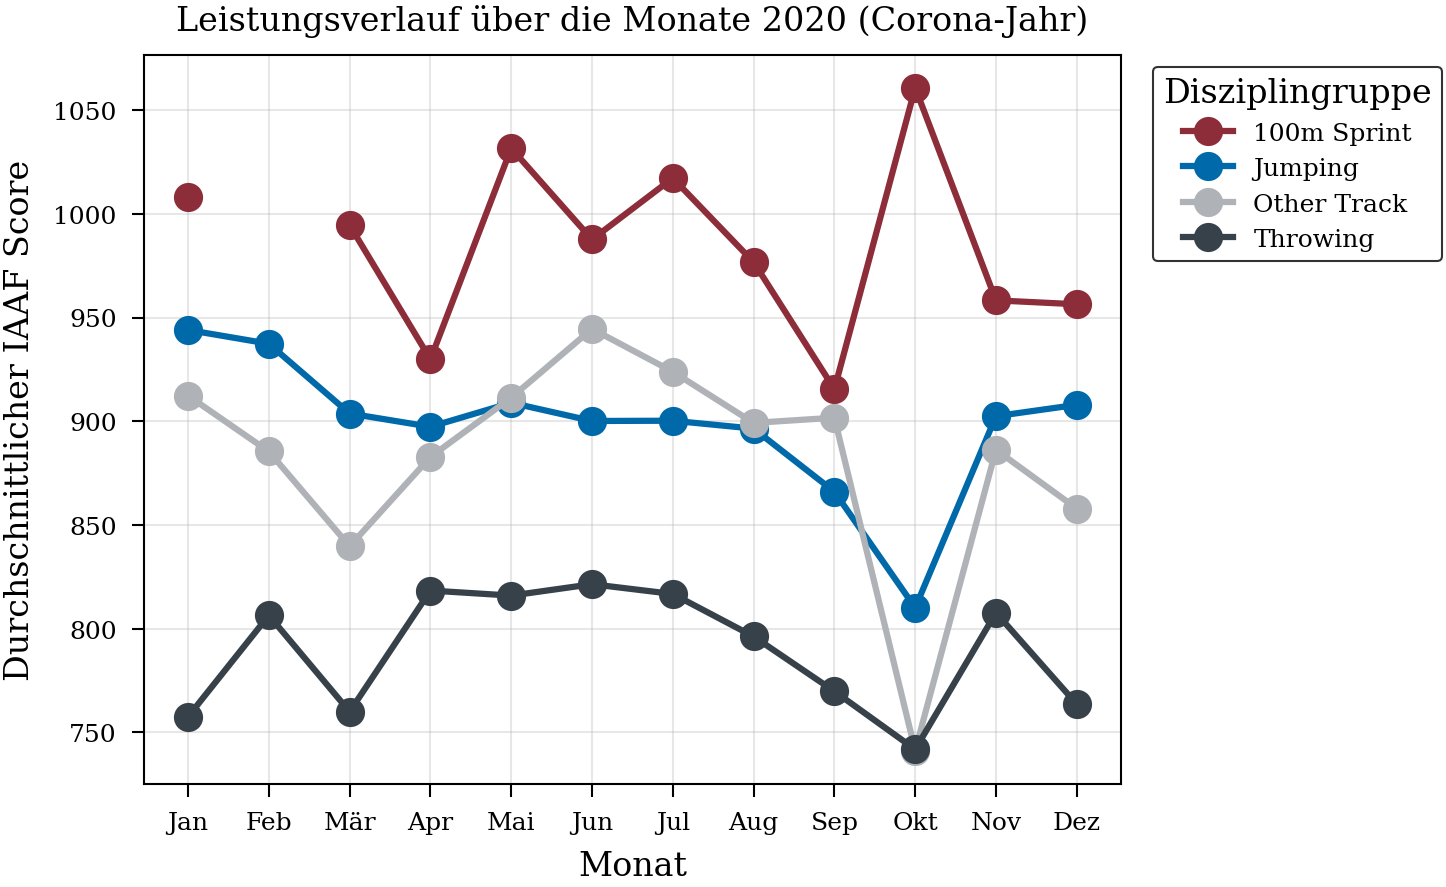

Grafik wurde im Ordner 'Plots/Corona_Impact/' gespeichert.


In [ ]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick

# --- PFAD-FIX ---
# Da util.py unter diesem Pfad liegt, fügen wir den Überordner zum Systempfad hinzu
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

# Jetzt können die Projekt-Module geladen werden
try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: Module konnten nicht geladen werden. Prüfe, ob der Pfad stimmt.")
    sys.exit()

# 1. Daten laden (Nutzt die interne Logik von util.py)
df = util.load_data()

# 2. Vorbereitung für monatliche Analyse 2020
# Wir stellen sicher, dass eine Datumsspalte existiert
if 'datum' not in df.columns:
    # Falls das Datum in einer anderen Spalte steckt, hier anpassen
    # Wir nehmen an, util.load_data() hat das Datum bereits bereinigt
    pass 

df['datum'] = pd.to_datetime(df['datum'], errors='coerce')
df['monat'] = df['datum'].dt.month
df['jahr'] = df['datum'].dt.year

# Filter auf das Jahr 2020
df_2020 = df[df['jahr'] == 2020].copy()

# 3. Kategorisierung (wie im Projekt definiert)
def categorize_disciplines(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df_2020['category'] = df_2020['disziplin'].apply(categorize_disciplines)

# 4. Berechnung: Durchschnittlicher Score pro Monat und Kategorie
monthly_stats = df_2020.groupby(['monat', 'category'])['iaaf_score'].mean().unstack()

# 5. Visualisierung im Tübingen/ICML-Style
# Wir nutzen plt.rc_context für die richtige Größe
with plt.rc_context(plt.increase_figsize(1.5)):
    fig, ax = plt.subplots()

    # Farben definieren (Tübingen Design)
    colors = {
        '100m Sprint': rgb.tue_red, 
        'Jumping': rgb.tue_blue, 
        'Throwing': rgb.tue_dark, 
        'Other Track': rgb.tue_gray, 
        'Combined Events': '#8B6914'
    }

    # Plotten der Linien
    for column in monthly_stats.columns:
        ax.plot(monthly_stats.index, monthly_stats[column], 
                label=column, 
                marker='o', 
                linewidth=1.5,
                color=colors.get(column, 'gray'))

    # Achsen-Beschriftung
    ax.set_title('Leistungsverlauf über die Monate 2020 (Corona-Jahr)')
    ax.set_xlabel('Monat')
    ax.set_ylabel('Durchschnittlicher IAAF Score')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
    
    # Gitter und Legende
    ax.grid(True, alpha=0.3)
    ax.legend(title='Disziplingruppe', loc='upper left', bbox_to_anchor=(1.02, 1))

    # Automatisches Speichern im zentralen Plots/ Ordner
    plt.savefig("monatliche_analyse_2020", category="Corona_Impact")
    
    plt.show()

print("Grafik wurde im Ordner 'Plots/Corona_Impact/' gespeichert.")

✅ Standard-Bibliotheken geladen.
✅ Projekt-Module (util, plotting) erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1528/1114901725.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_30_std = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin']).apply(get_top_30_std).reset_index(name='sd_score')
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1528/1114901725.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_sd_stats = 

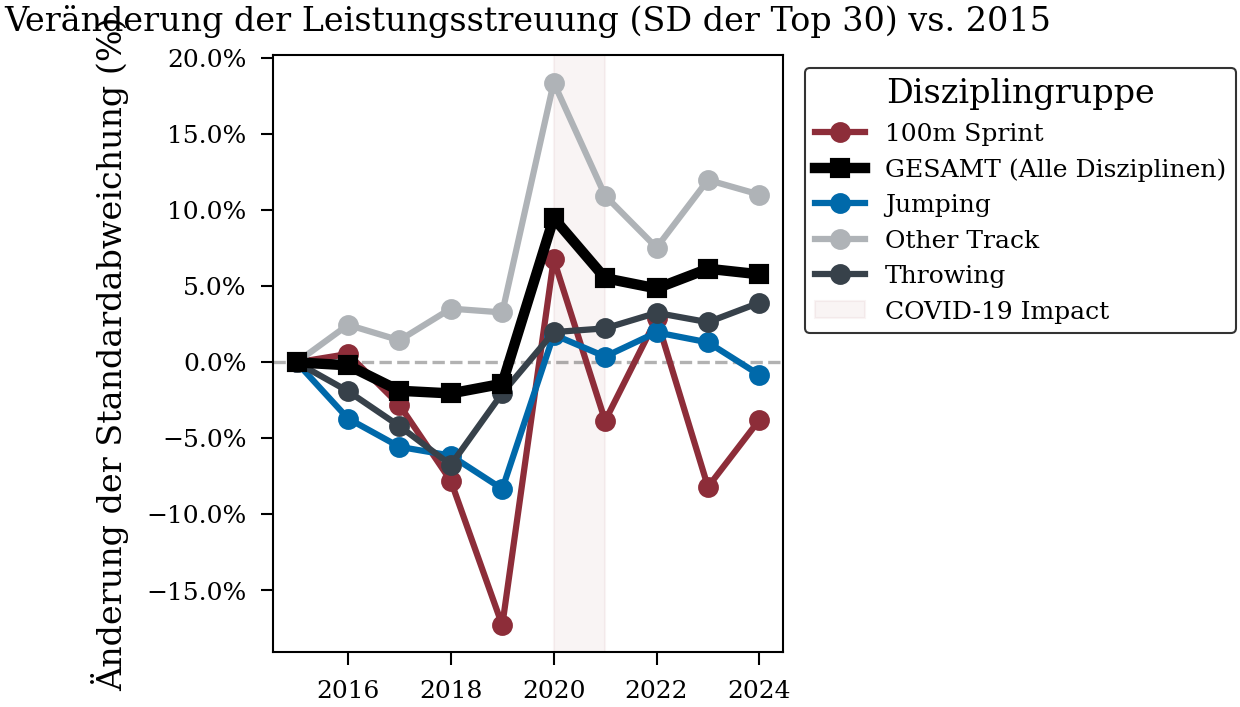

In [1]:
import os
import sys

# --- 1. PFAD-FIX (Zuerst den Pfad setzen, dann Module laden) ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    # Wir fügen den Pfad am Ende ein, um System-Bibliotheken nicht zu überschreiben
    sys.path.append(repo_path)

# --- 2. SICHERER IMPORT VON STANDARD-BIBLIOTHEKEN ---
try:
    import pandas as pd
    import matplotlib.ticker as mtick
    print("✅ Standard-Bibliotheken geladen.")
except RecursionError:
    print("❌ Immer noch RecursionError. Bitte den Kernel (Restart) neu starten!")
    raise

# --- 3. PROJEKT-SPEZIFISCHE IMPORTS ---
try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module (util, plotting) erfolgreich geladen.")
except ImportError as e:
    print(f"❌ Fehler beim Laden der Projekt-Module: {e}")
    sys.exit()

# --- 4. DATEN LADEN & KATEGORISIEREN ---
# Nutzt die zentrale util-Funktion deines Projekts
df = util.load_data()

def categorize(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df['category'] = df['disziplin'].apply(categorize)
df_recent = df[df['jahr'] >= 2015].copy()

# --- 5. BERECHNUNG DER STANDARDABWEICHUNG ---
def get_top_30_std(group):
    top_30 = group.nlargest(30, 'iaaf_score')['iaaf_score']
    return top_30.std()

# SD pro Gruppe berechnen
top_30_std = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin']).apply(get_top_30_std).reset_index(name='sd_score')

# Aggregation für den Plot
category_sd = top_30_std.groupby(['jahr', 'category'])['sd_score'].mean().reset_index()
total_sd = top_30_std.groupby(['jahr'])['sd_score'].mean().reset_index()
total_sd['category'] = 'GESAMT (Alle Disziplinen)'

final_sd_stats = pd.concat([category_sd, total_sd], ignore_index=True)

# Prozentuale Änderung berechnen
def calculate_pct_change(group):
    base_val = group.loc[group['jahr'] == 2015, 'sd_score']
    if not base_val.empty and base_val.values[0] != 0:
        b = base_val.values[0]
        group['sd_rel_change_pct'] = ((group['sd_score'] - b) / b) * 100
    else:
        group['sd_rel_change_pct'] = 0
    return group

final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

# --- 6. VISUALISIERUNG ---
with plt.rc_context(plt.increase_figsize(1.2)):
    fig, ax = plt.subplots()

    colors = {
        '100m Sprint': rgb.tue_red, 
        'Jumping': rgb.tue_blue, 
        'Throwing': rgb.tue_dark, 
        'Other Track': rgb.tue_gray, 
        'Combined Events': '#8B6914',
        'GESAMT (Alle Disziplinen)': 'black'
    }

    for cat in sorted(final_sd_stats['category'].unique()):
        cat_data = final_sd_stats[final_sd_stats['category'] == cat].sort_values('jahr')
        
        is_gesamt = 'GESAMT' in cat
        lw = 2.5 if is_gesamt else 1.5
        z = 10 if is_gesamt else 5
        marker = 's' if is_gesamt else 'o'
        
        ax.plot(cat_data['jahr'], cat_data['sd_rel_change_pct'], 
                label=cat, color=colors.get(cat, 'gray'), 
                linewidth=lw, zorder=z, marker=marker, markersize=4)

    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3, linestyle='--')
    ax.axvspan(2020, 2021, color=rgb.tue_red, alpha=0.05, label='COVID-19 Impact')
    
    ax.set_title('Veränderung der Leistungsstreuung (SD der Top 30) vs. 2015')
    ax.set_ylabel('Änderung der Standardabweichung (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    ax.legend(title='Disziplingruppe', loc='upper left', bbox_to_anchor=(1.02, 1))

    # Speichert automatisch in den Projekt-Ordner Plots/
    plt.savefig("standard_deviation_trends", category="Leistungsanalyse")
    plt.show()

✅ Projekt-Module erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1970/3882275356.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datum'] = pd.to_datetime(df['datum'], errors='coerce')


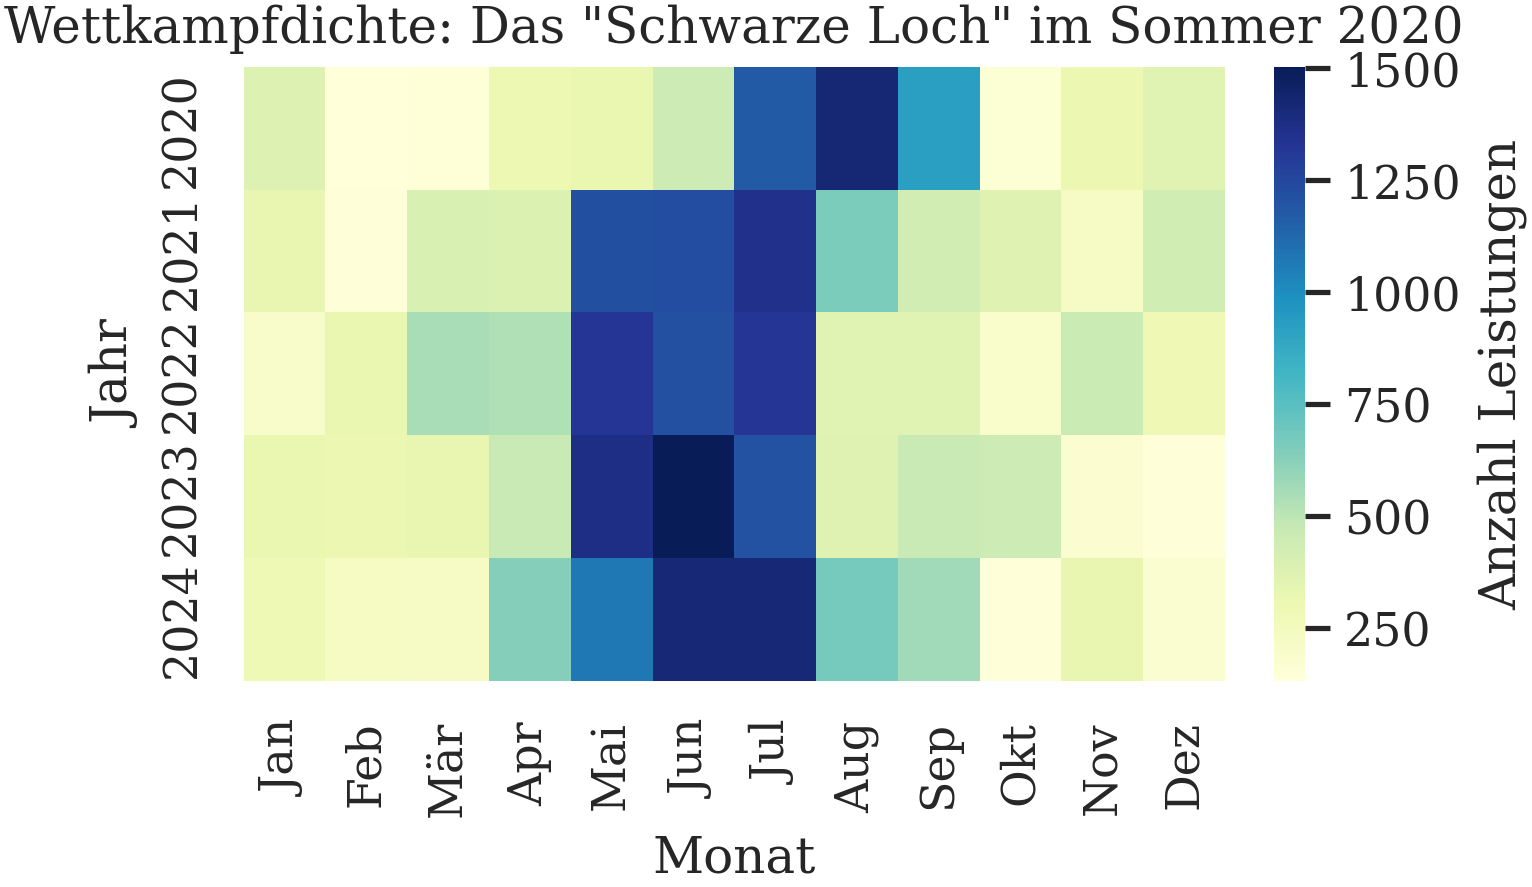

/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1970/3882275356.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap = year_data.groupby('disziplin').apply(
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1970/3882275356.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap = year_data.groupby('disziplin').apply(
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1970/3882275356.p

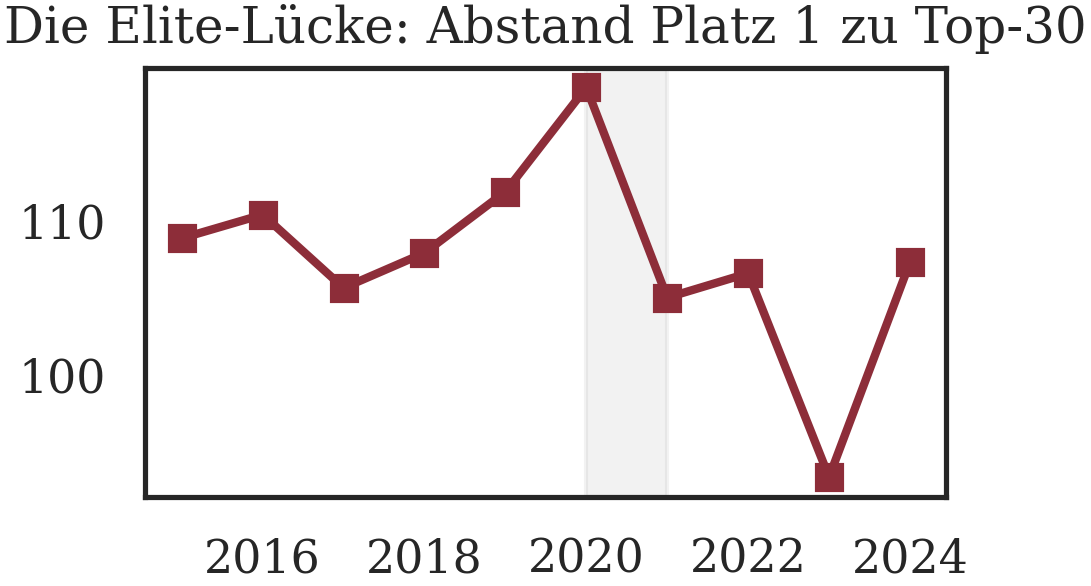

In [5]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick

# --- 1. PFAD-SETUP ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: Module konnten nicht geladen werden.")
    sys.exit()

# --- 2. DATEN LADEN & VORBEREITEN ---
df = util.load_data()

# Monat für die Heatmap extrahieren
df['datum'] = pd.to_datetime(df['datum'], errors='coerce')
df['monat'] = df['datum'].dt.month

# Kategorisierung (Senior-Standard: Fokus auf Hauptgruppen)
def categorize(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return 'Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    return 'Other'

df['category'] = df['disziplin'].apply(categorize)

# ---------------------------------------------------------
# ANALYSE 1: Das "Saisonale Schwarze Loch" (Heatmap)
# ---------------------------------------------------------
# Wir schauen uns an, wie viele Leistungen pro Monat erzielt wurden.
activity = df[df['jahr'] >= 2017].groupby(['jahr', 'monat']).size().unstack(fill_value=0)

with plt.rc_context(plt.increase_figsize(1.5)):
    fig, ax = plt.subplots()
    sns.heatmap(activity, cmap="YlGnBu", ax=ax, cbar_kws={'label': 'Anzahl Leistungen'})
    
    ax.set_title('Wettkampfdichte: Das "Schwarze Loch" im Sommer 2020')
    ax.set_xlabel('Monat')
    ax.set_ylabel('Jahr')
    ax.set_xticklabels(['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
    
    plt.savefig("activity_heatmap_corona", category="Senior_Analysis")
    plt.show()

# ---------------------------------------------------------
# ANALYSE 2: Der "Elite-Gap" (Top 1 vs. Top 30)
# ---------------------------------------------------------
# Hat sich die absolute Spitze von der Breite der Elite entkoppelt?
stats = []
for year in range(2015, 2025):
    year_data = df[df['jahr'] == year]
    if not year_data.empty:
        # Wir berechnen den Abstand pro Disziplin und nehmen dann den Schnitt
        gap = year_data.groupby('disziplin').apply(
            lambda x: x['iaaf_score'].max() - x.nlargest(30, 'iaaf_score')['iaaf_score'].mean()
        ).mean()
        stats.append({'jahr': year, 'gap': gap})

df_gap = pd.DataFrame(stats)

with plt.rc_context(plt.increase_figsize(1.0)):
    fig, ax = plt.subplots()
    ax.plot(df_gap['jahr'], df_gap['gap'], marker='s', color=rgb.tue_red, linewidth=2)
    
    ax.axvspan(2020, 2021, color='gray', alpha=0.1, label='Haupt-Pandemiephase')
    ax.set_title('Die Elite-Lücke: Abstand Platz 1 zu Top-30')

✅ Projekt-Module erfolgreich geladen.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


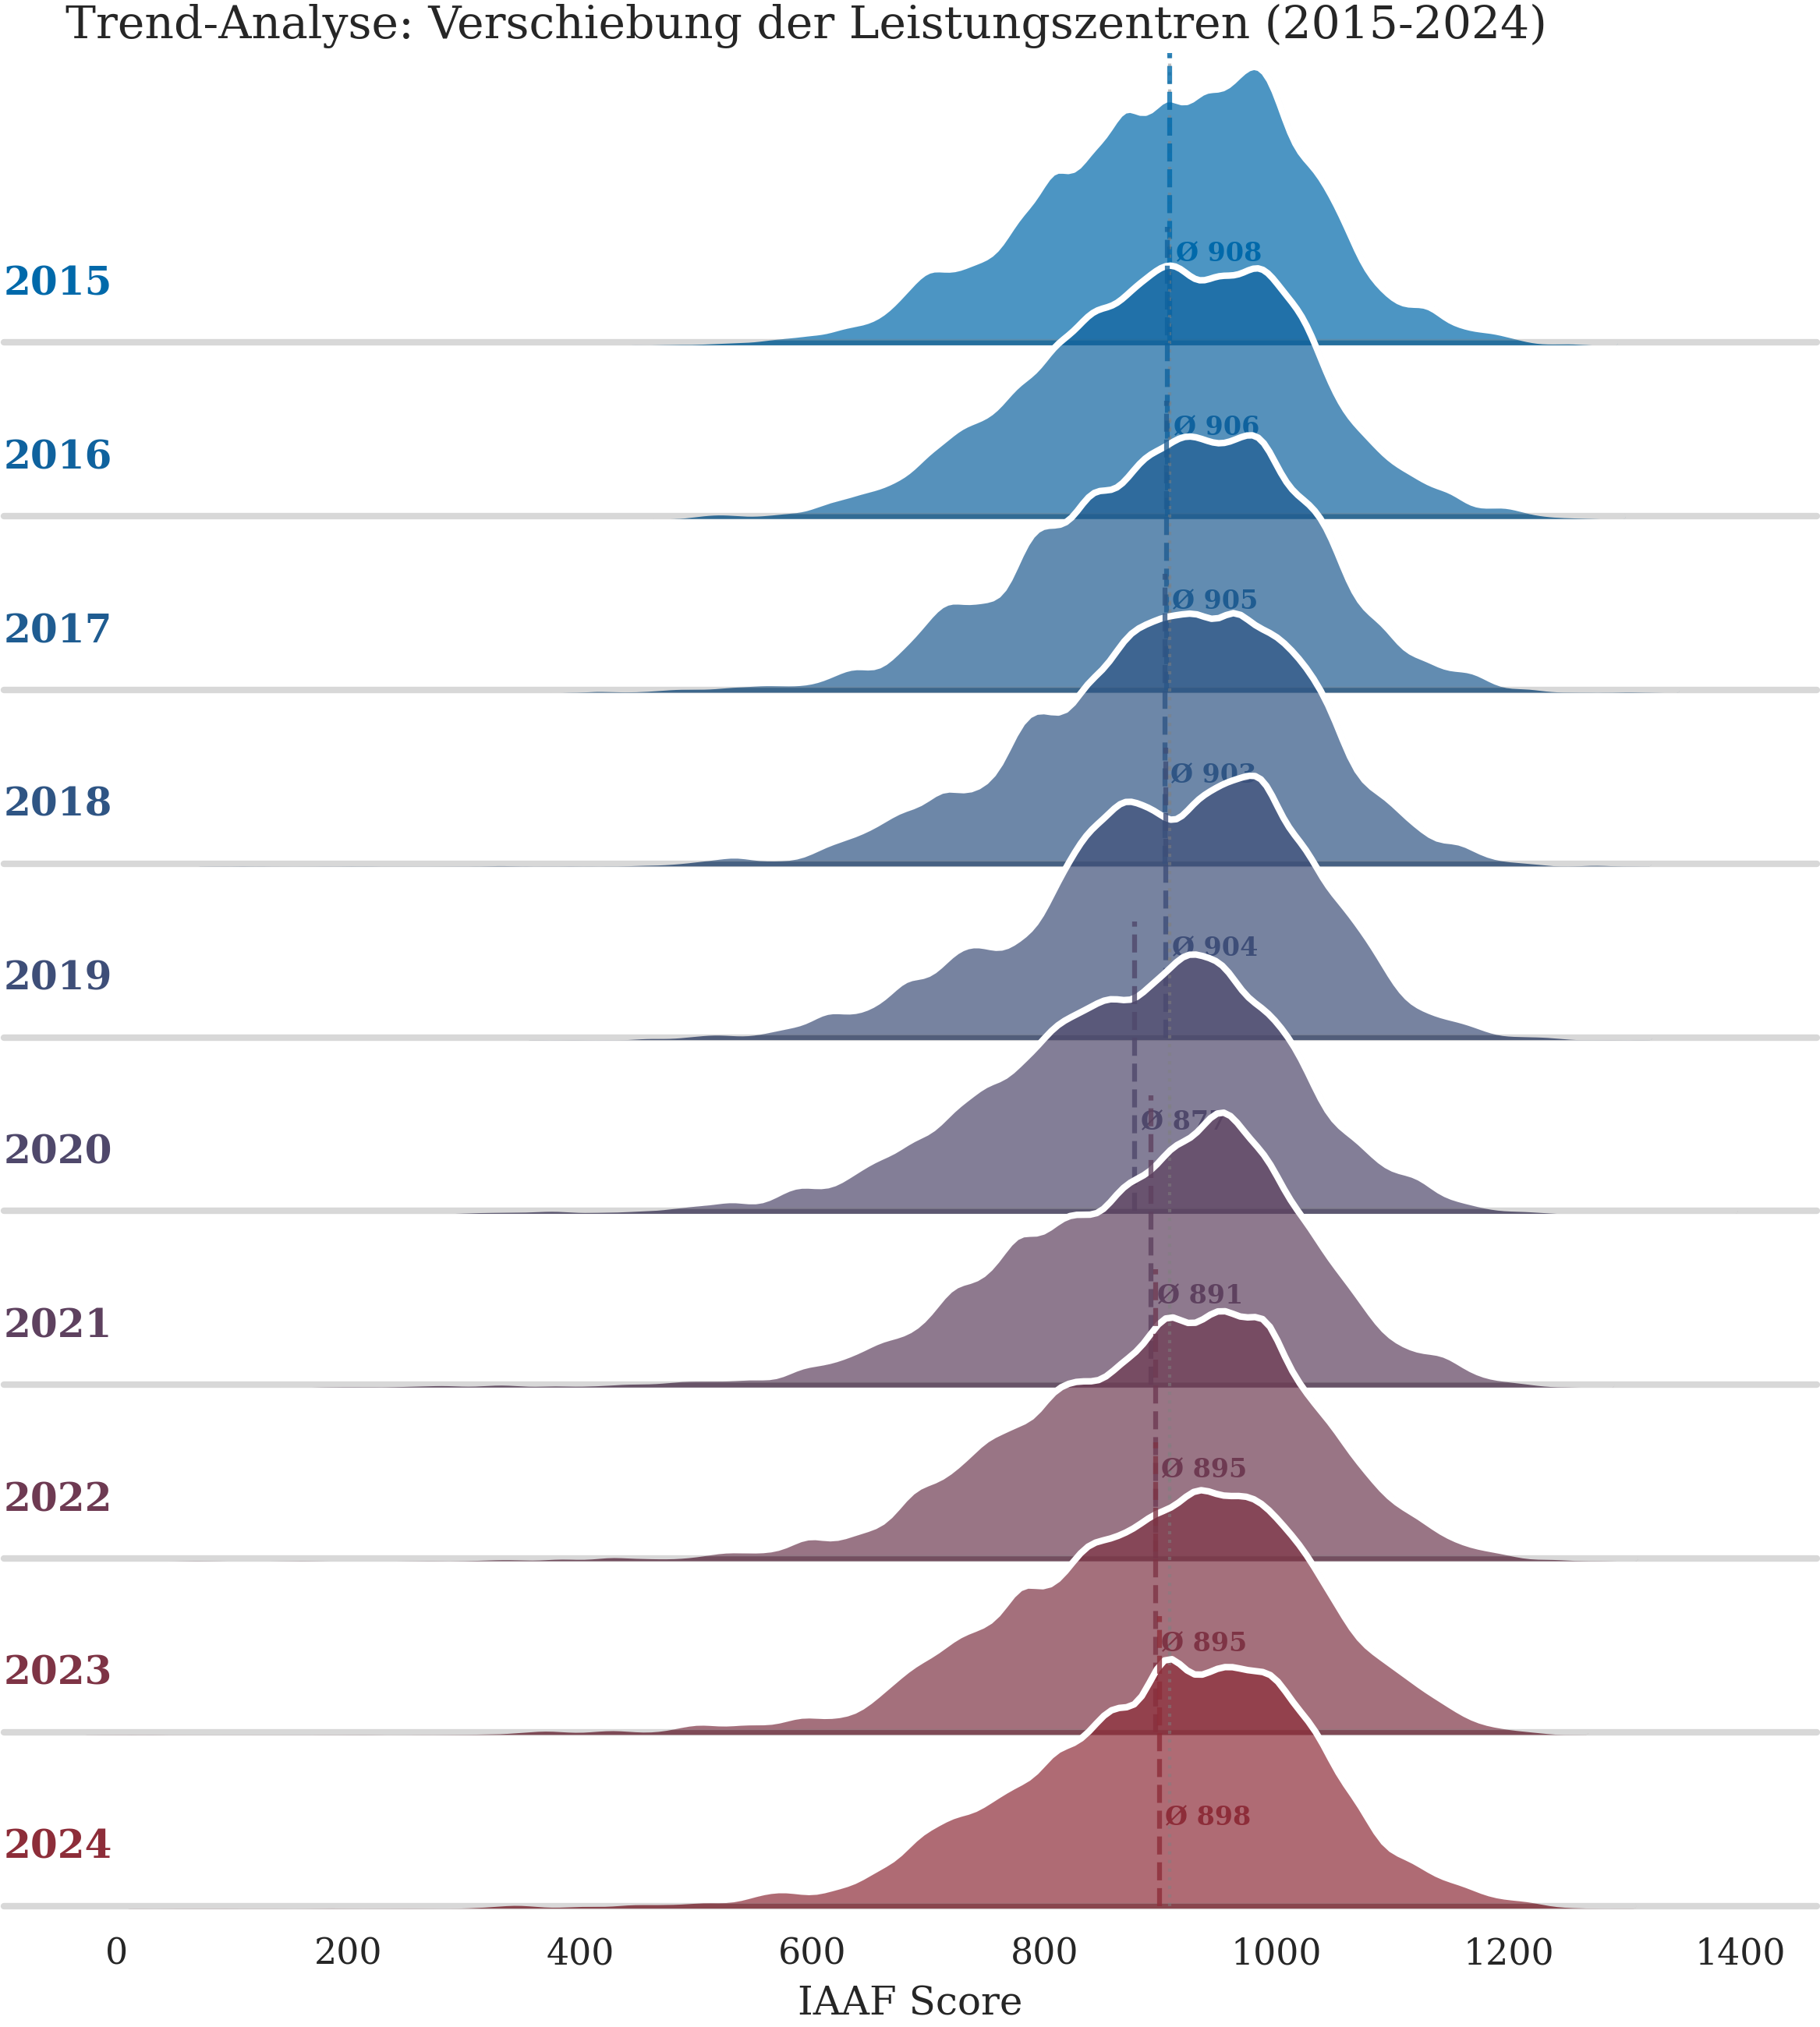

In [3]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PFAD-SETUP ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as pstyle
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: Module konnten nicht geladen werden.")
    sys.exit()

# --- 2. DATEN LADEN & BERECHNEN ---
df = util.load_data()
df_plot = df[df['jahr'] >= 2015].copy()

# Berechne den globalen Mittelwert von 2015 als Referenz (Baseline)
baseline_2015 = df_plot[df_plot['jahr'] == 2015]['iaaf_score'].mean()

# --- 3. RIDGE PLOT SETUP ---
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0), "font.family": "serif"})
years = sorted(df_plot['jahr'].unique())
pal = sns.blend_palette([rgb.tue_blue, rgb.tue_red], n_colors=len(years))

g = sns.FacetGrid(df_plot, row="jahr", hue="jahr", aspect=10, height=.9, palette=pal)

# --- 4. FUNKTION FÜR MITTELWERTE & TRENDS ---
def draw_stats(data, color, **kwargs):
    ax = plt.gca()
    current_mean = data['iaaf_score'].mean()
    
    # 1. Die Baseline (2015) als graue Referenzlinie in jedem Plot
    ax.axvline(baseline_2015, color='gray', linestyle=':', lw=1, alpha=0.5, zorder=1)
    
    # 2. Der aktuelle Mittelwert als farbige gestrichelte Linie
    ax.axvline(current_mean, color=color, linestyle='--', lw=1.5, alpha=0.8, zorder=2)
    
    # 3. Optional: Kleiner Text mit dem exakten Mittelwert
    ax.text(current_mean + 5, 0.001, f'Ø {int(current_mean)}', 
            color=color, fontsize=8, fontweight='bold', va='bottom')

# --- 5. ZEICHNEN ---
# Die Wellen
g.map(sns.kdeplot, "iaaf_score", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "iaaf_score", clip_on=False, color="w", lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color="gray", alpha=0.3)

# Die statistischen Linien (Mittelwert pro Jahr)
g.map_dataframe(draw_stats)

# Labels für die Jahre
def label_years(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label_years, "iaaf_score")

# Layout-Anpassung
g.figure.subplots_adjust(hspace=-0.4)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.xlabel("IAAF Score", fontsize=12)
plt.suptitle("Trend-Analyse: Verschiebung der Leistungszentren (2015-2024)", fontsize=14, y=0.98)

# Speichern
pstyle.savefig("performance_ridge_trend_stats", category="Senior_Analysis")
plt.show()

✅ Projekt-Module erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1970/1390484524.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)


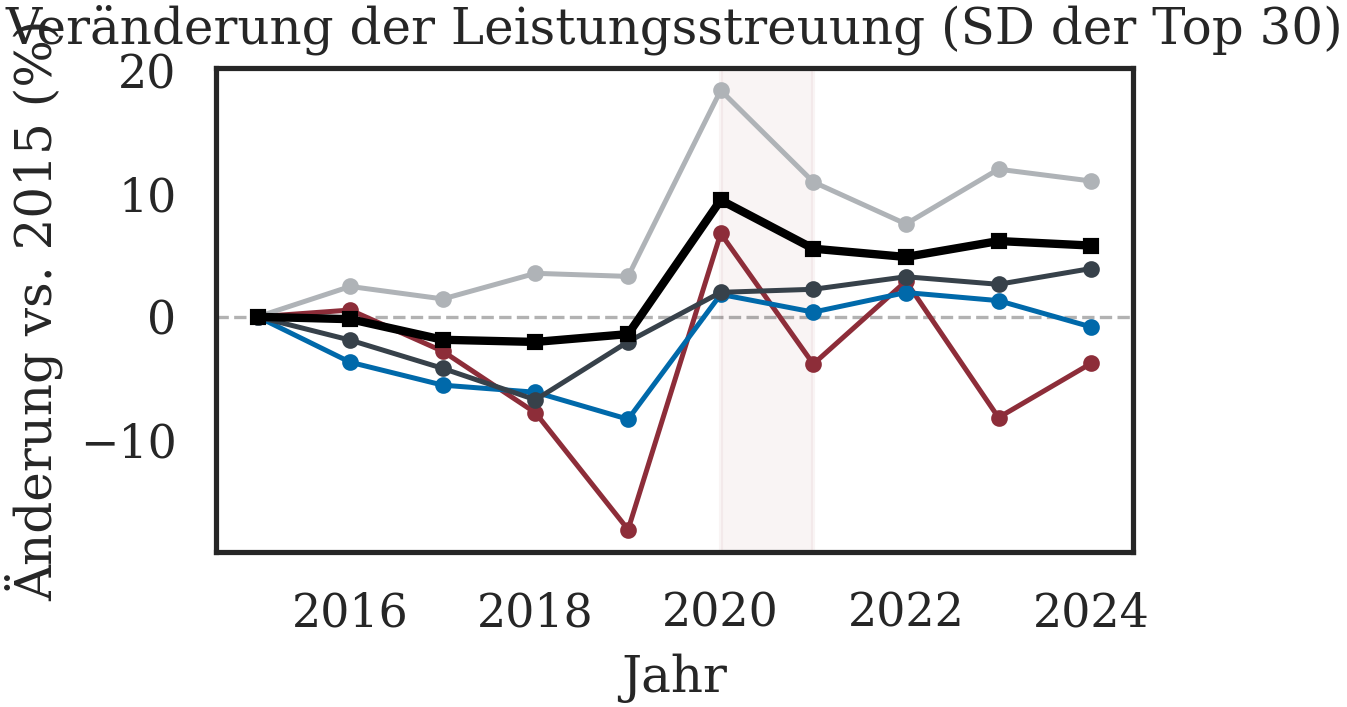

In [12]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick

# --- 1. PROJEKT-SETUP ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: util.py oder plotting_style.py nicht gefunden.")
    sys.exit()

# --- 2. DATEN LADEN & KATEGORISIEREN ---
df = util.load_data()

def categorize(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df['category'] = df['disziplin'].apply(categorize)
df_recent = df[df['jahr'] >= 2015].copy()

# --- 3. BERECHNUNG DER SD (TOP 30) ---
# Fix für die FutureWarning: Wir gruppieren und wählen die Spalte iaaf_score direkt aus
top_30_std = (df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin'])['iaaf_score']
              .apply(lambda x: x.nlargest(30).std())
              .reset_index(name='sd_score'))

# Aggregation auf Kategorien
category_sd = top_30_std.groupby(['jahr', 'category'])['sd_score'].mean().reset_index()
total_sd = top_30_std.groupby(['jahr'])['sd_score'].mean().reset_index()
total_sd['category'] = 'GESAMT (Alle Disziplinen)'

final_sd_stats = pd.concat([category_sd, total_sd], ignore_index=True)

# Prozentuale Änderung berechnen
def calculate_pct_change(group):
    base_val = group.loc[group['jahr'] == 2015, 'sd_score']
    if not base_val.empty and base_val.values[0] != 0:
        b = base_val.values[0]
        group['sd_rel_change_pct'] = ((group['sd_score'] - b) / b) * 100
    else:
        group['sd_rel_change_pct'] = 0
    return group

final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

# --- 4. VISUALISIERUNG ---
color_map = {
    '100m Sprint': rgb.tue_red, 
    'Jumping': rgb.tue_blue, 
    'Throwing': rgb.tue_dark, 
    'Other Track': rgb.tue_gray, 
    'Combined Events': '#8B6914',
    'GESAMT (Alle Disziplinen)': 'black'
}

with plt.rc_context(plt.increase_figsize(1.2)):
    fig, ax = plt.subplots()

    for cat in sorted(final_sd_stats['category'].unique()):
        cat_data = final_sd_stats[final_sd_stats['category'] == cat].sort_values('jahr')
        
        is_gesamt = 'GESAMT' in cat
        lw = 2.0 if is_gesamt else 1.2
        z = 10 if is_gesamt else 5
        marker = 's' if is_gesamt else 'o'
        
        ax.plot(cat_data['jahr'], cat_data['sd_rel_change_pct'], 
                label=cat, color=color_map.get(cat, 'gray'), 
                linewidth=lw, zorder=z, marker=marker, markersize=3)

    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3, linestyle='--')
    ax.axvspan(2020, 2021, color=rgb.tue_red, alpha=0.05, label='COVID-19 Impact')
    
    ax.set_title('Veränderung der Leistungsstreuung (SD der Top 30)')
    ax.set_ylabel('Änderung vs. 2015 (%)')
    ax.set_xlabel('Jahr')

✅ Projekt-Module erfolgreich geladen.


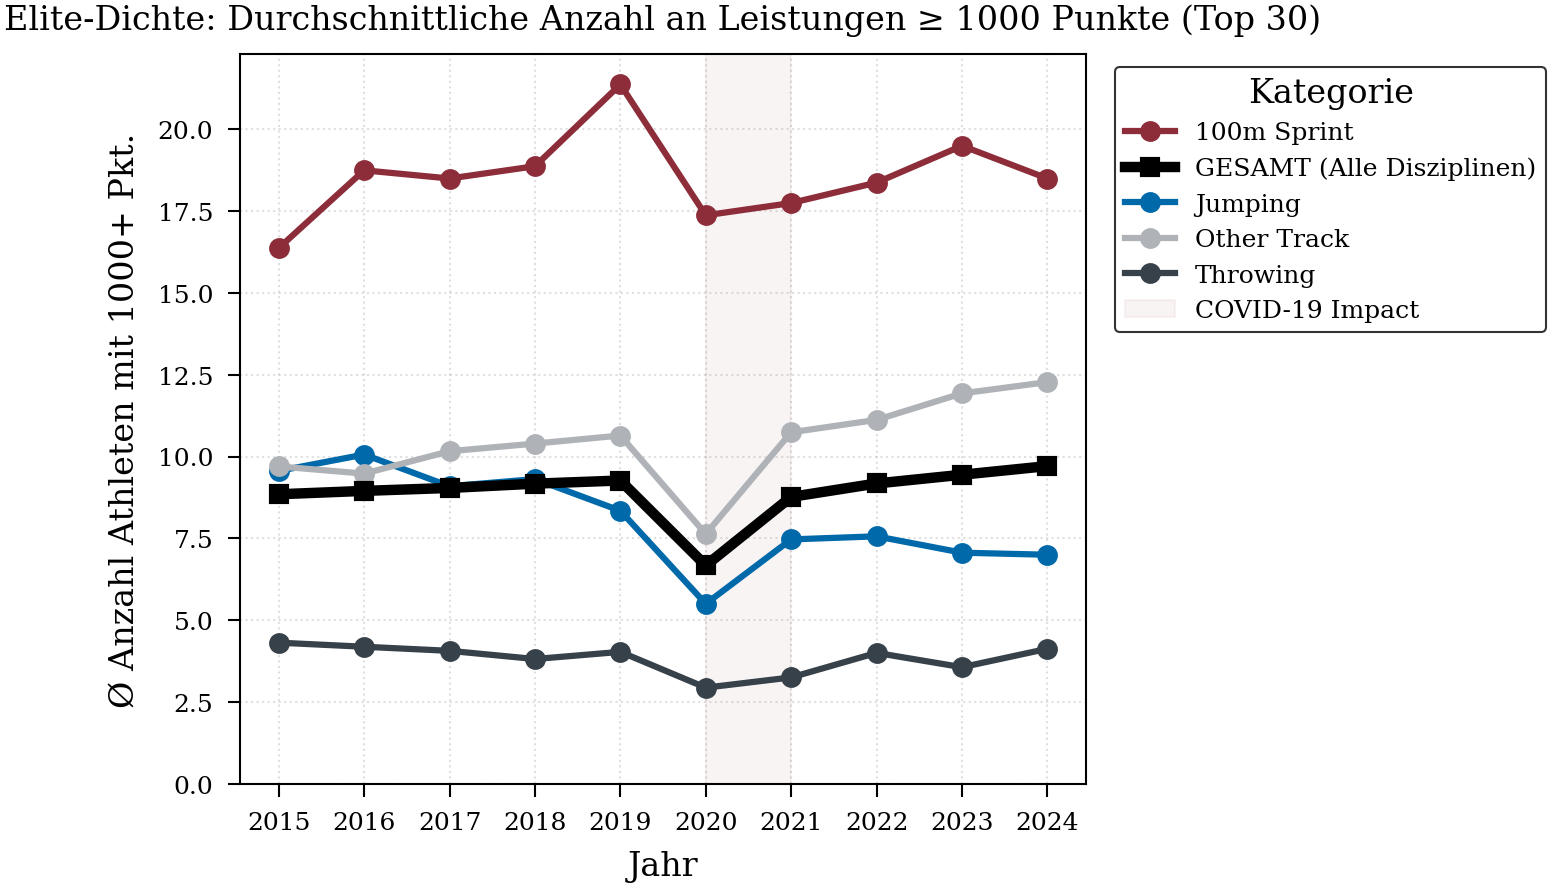


--- Vergleich 2019 vs. 2020 (Elite-Dichte) ---
jahr                       differenz
category                            
100m Sprint                -4.000000
Other Track                -3.008700
Jumping                    -2.843750
GESAMT (Alle Disziplinen)  -2.597733
Throwing                   -1.093750


In [1]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick

# --- 1. PROJEKT-SETUP ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: util.py oder plotting_style.py nicht gefunden.")
    sys.exit()

# --- 2. DATEN LADEN & KATEGORISIEREN ---
df = util.load_data()

def categorize(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df['category'] = df['disziplin'].apply(categorize)
df_recent = df[df['jahr'] >= 2015].copy()

# --- 3. BERECHNUNG DER ELITE-DICHTE (> 1000 PUNKTE) ---
# Wir zählen, wie viele Leistungen pro Top-30-Liste über 1000 Punkte liegen
def count_over_1000(group):
    top_30 = group.nlargest(30, 'iaaf_score')
    return (top_30['iaaf_score'] >= 1000).sum()

# Berechnung pro Disziplin-Gruppe
elite_counts = (df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin'])['iaaf_score']
                .apply(lambda x: (x.nlargest(30) >= 1000).sum())
                .reset_index(name='count_1000'))

# Aggregation: Durchschnittliche Anzahl an "Elite-Leistungen" pro Disziplin in der Kategorie
category_elite = elite_counts.groupby(['jahr', 'category'])['count_1000'].mean().reset_index()
total_elite = elite_counts.groupby(['jahr'])['count_1000'].mean().reset_index()
total_elite['category'] = 'GESAMT (Alle Disziplinen)'

final_elite_stats = pd.concat([category_elite, total_elite], ignore_index=True)

# --- 4. VISUALISIERUNG (TÜBINGEN STYLE) ---
color_map = {
    '100m Sprint': rgb.tue_red, 
    'Jumping': rgb.tue_blue, 
    'Throwing': rgb.tue_dark, 
    'Other Track': rgb.tue_gray, 
    'Combined Events': '#8B6914',
    'GESAMT (Alle Disziplinen)': 'black'
}

with plt.rc_context(plt.increase_figsize(1.5)):
    fig, ax = plt.subplots()

    for cat in sorted(final_elite_stats['category'].unique()):
        cat_data = final_elite_stats[final_elite_stats['category'] == cat].sort_values('jahr')
        
        is_gesamt = 'GESAMT' in cat
        lw = 2.5 if is_gesamt else 1.5
        z = 10 if is_gesamt else 5
        marker = 's' if is_gesamt else 'o'
        
        ax.plot(cat_data['jahr'], cat_data['count_1000'], 
                label=cat, color=color_map.get(cat, 'gray'), 
                linewidth=lw, zorder=z, marker=marker, markersize=4)

    # COVID-19 Markierung
    ax.axvspan(2020, 2021, color=rgb.tue_red, alpha=0.05, label='COVID-19 Impact')
    
    # Achsen-Gestaltung
    ax.set_title('Elite-Dichte: Durchschnittliche Anzahl an Leistungen ≥ 1000 Punkte (Top 30)')
    ax.set_ylabel('Ø Anzahl Athleten mit 1000+ Pkt.')
    ax.set_xlabel('Jahr')
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(1))
    ax.grid(True, linestyle=':', alpha=0.4)
    
    # Y-Achse bei 0 starten lassen für ehrliche Darstellung
    ax.set_ylim(bottom=0)
    
    ax.legend(title='Kategorie', loc='upper left', bbox_to_anchor=(1.02, 1))

    plt.savefig("elite_density_1000_trend", category="Leistungsanalyse")
    plt.show()

# --- 5. KURZE ANALYSE ---
print("\n--- Vergleich 2019 vs. 2020 (Elite-Dichte) ---")
comp = final_elite_stats[final_elite_stats['jahr'].isin([2019, 2020])].pivot(index='category', columns='jahr', values='count_1000')
comp['differenz'] = comp[2020] - comp[2019]
print(comp[['differenz']].sort_values('differenz'))

✅ Projekt-Module erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_5333/3005350672.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)


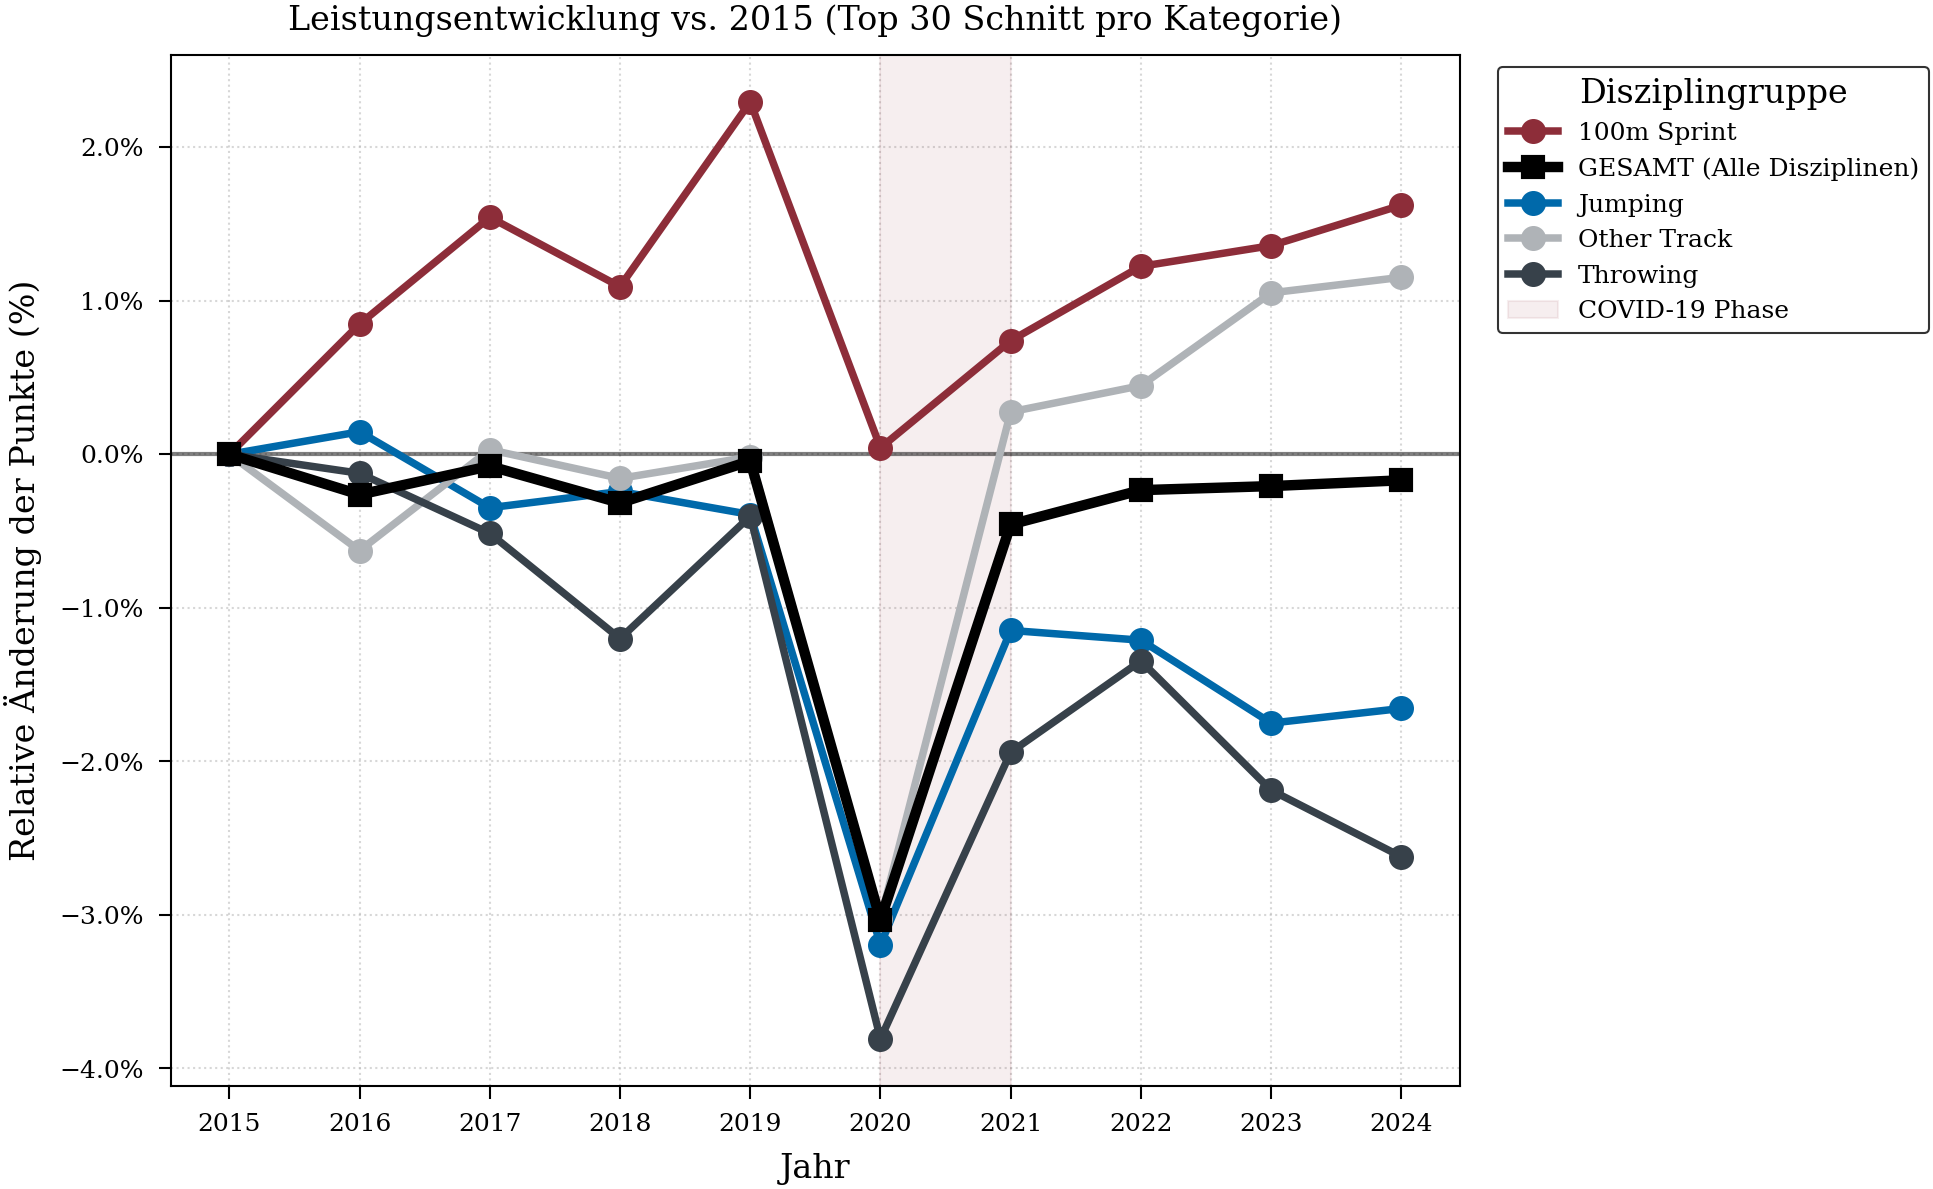

✅ Der Plot wurde vergrößert unter 'Plots/Corona_Analyse/' gespeichert.


In [4]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick

# --- 1. PROJEKT-SETUP & PFADE ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: util.py oder plotting_style.py nicht gefunden.")
    sys.exit()

# --- 2. DATEN LADEN & KATEGORISIEREN ---
df = util.load_data()

def categorize(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df['category'] = df['disziplin'].apply(categorize)
df_recent = df[df['jahr'] >= 2015].copy()

# --- 3. TOP 30 BERECHNUNG ---
# Berechnung des Mittelwerts der Top 30 pro Wettbewerb
top_30_stats = (df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin'])['iaaf_score']
                .apply(lambda x: x.nlargest(30).mean())
                .reset_index(name='iaaf_score'))

# Aggregation auf Kategorie-Ebene
category_stats = top_30_stats.groupby(['jahr', 'category'])['iaaf_score'].mean().reset_index()
total_stats = top_30_stats.groupby(['jahr'])['iaaf_score'].mean().reset_index()
total_stats['category'] = 'GESAMT (Alle Disziplinen)'

final_stats = pd.concat([category_stats, total_stats], ignore_index=True)

# Prozentuale Änderung berechnen (Basisjahr 2015)
def calculate_pct_change(group):
    base_val = group.loc[group['jahr'] == 2015, 'iaaf_score']
    if not base_val.empty:
        b = base_val.values[0]
        group['rel_change_pct'] = ((group['iaaf_score'] - b) / b) * 100
    else:
        group['rel_change_pct'] = 0
    return group

final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

# --- 4. VISUALISIERUNG (GROSSES FORMAT & TUEPLOTS) ---
colors = {
    '100m Sprint': rgb.tue_red, 
    'Jumping': rgb.tue_blue, 
    'Throwing': rgb.tue_dark,
    'Other Track': rgb.tue_gray, 
    'Combined Events': '#8B6914', 
    'GESAMT (Alle Disziplinen)': 'black'
}

# Faktor 2.0 für eine deutlich größere Darstellung im Notebook
with plt.rc_context(plt.increase_figsize(2.0)):
    fig, ax = plt.subplots()
    
    for cat in sorted(final_stats['category'].unique()):
        cat_data = final_stats[final_stats['category'] == cat].sort_values('jahr')
        
        is_gesamt = 'GESAMT' in cat
        lw = 2.5 if is_gesamt else 1.8
        z = 10 if is_gesamt else 5
        marker = 's' if is_gesamt else 'o'
        
        ax.plot(cat_data['jahr'], cat_data['rel_change_pct'], 
                label=cat, color=colors.get(cat, 'gray'), 
                linewidth=lw, zorder=z, marker=marker, markersize=5)

    # Hilfslinien & Layout
    ax.axhline(0, color='black', linewidth=1.0, alpha=0.5, linestyle='-')
    ax.axvspan(2020, 2021, color=rgb.tue_red, alpha=0.08, label='COVID-19 Phase')
    
    # X-Achse: Jedes Jahr einzeln anzeigen
    ax.xaxis.set_major_locator(mtick.MultipleLocator(1))
    
    # Y-Achse: Prozentformatierung
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    # Labels & Titel
    ax.set_title('Leistungsentwicklung vs. 2015 (Top 30 Schnitt pro Kategorie)')
    ax.set_ylabel('Relative Änderung der Punkte (%)')
    ax.set_xlabel('Jahr')
    
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # Legende rechts außerhalb platzieren
    ax.legend(title='Disziplingruppe', loc='upper left', bbox_to_anchor=(1.02, 1))
    
    # Speichern
    plt.savefig("leistungsentwicklung_detail_large", category="Corona_Analyse")
    plt.show()

print("✅ Der Plot wurde vergrößert unter 'Plots/Corona_Analyse/' gespeichert.")

✅ Projekt-Module erfolgreich geladen.


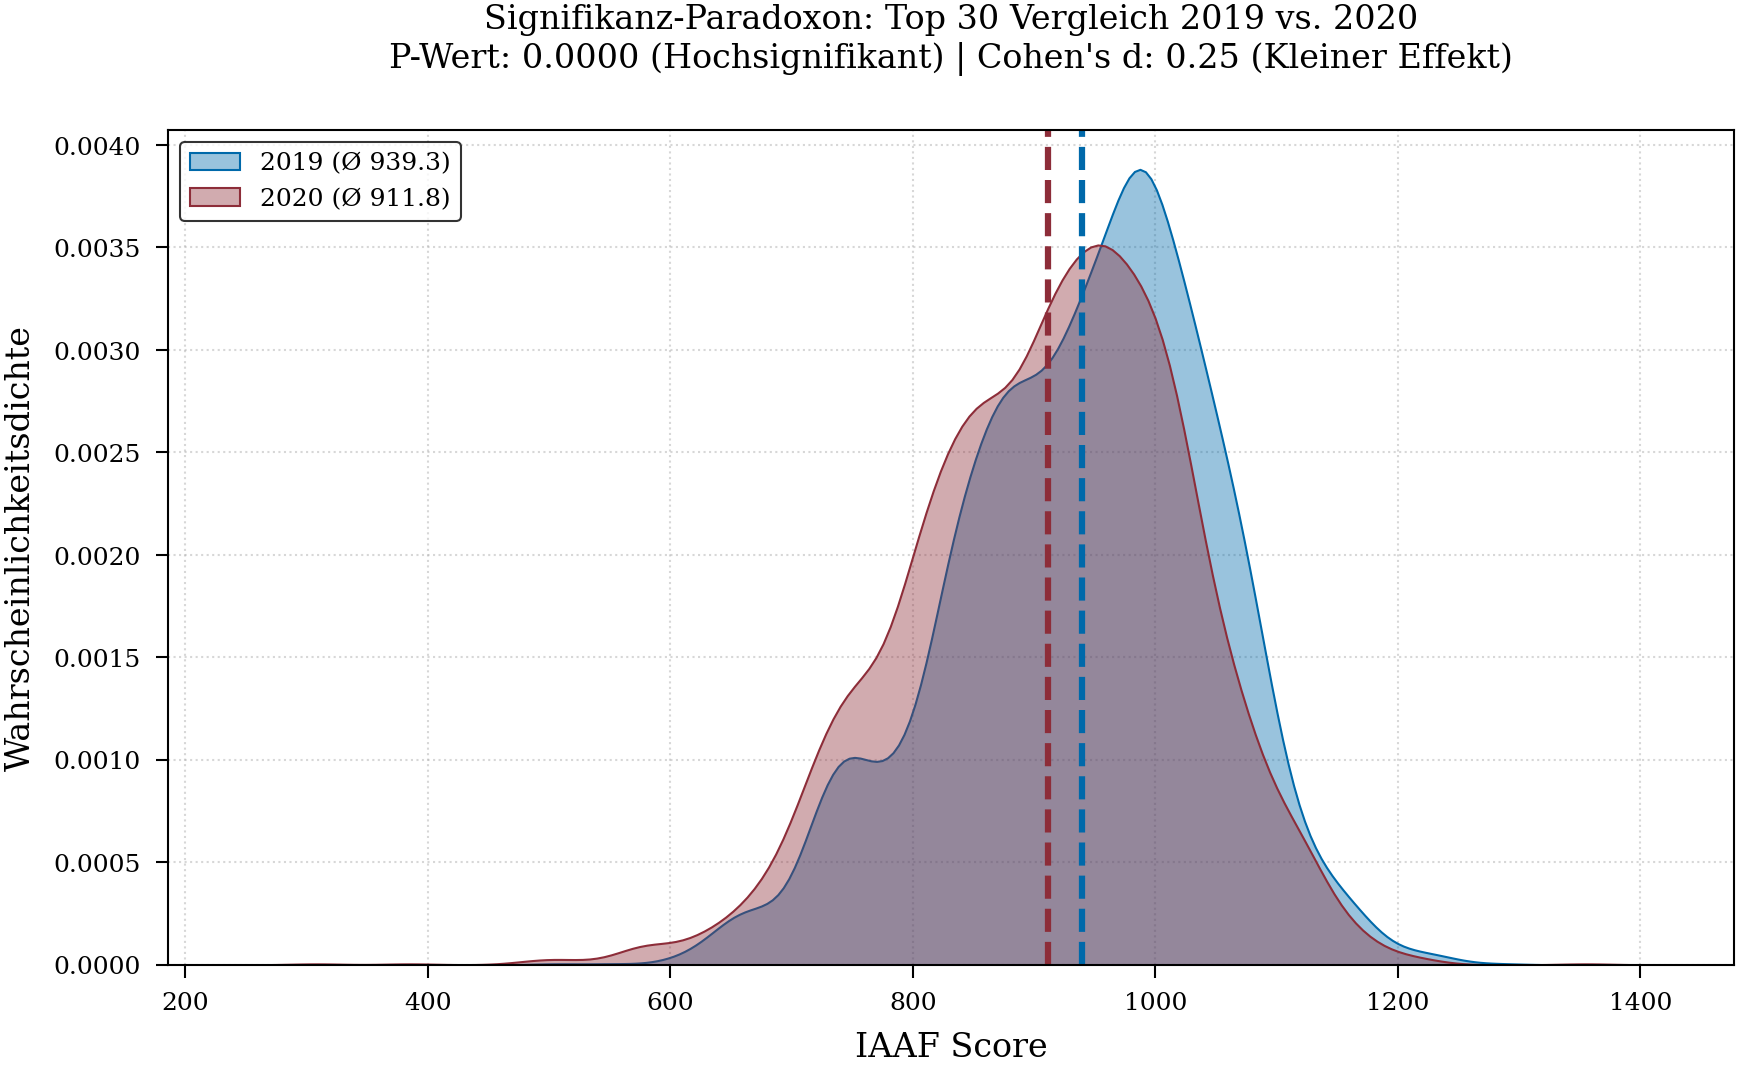

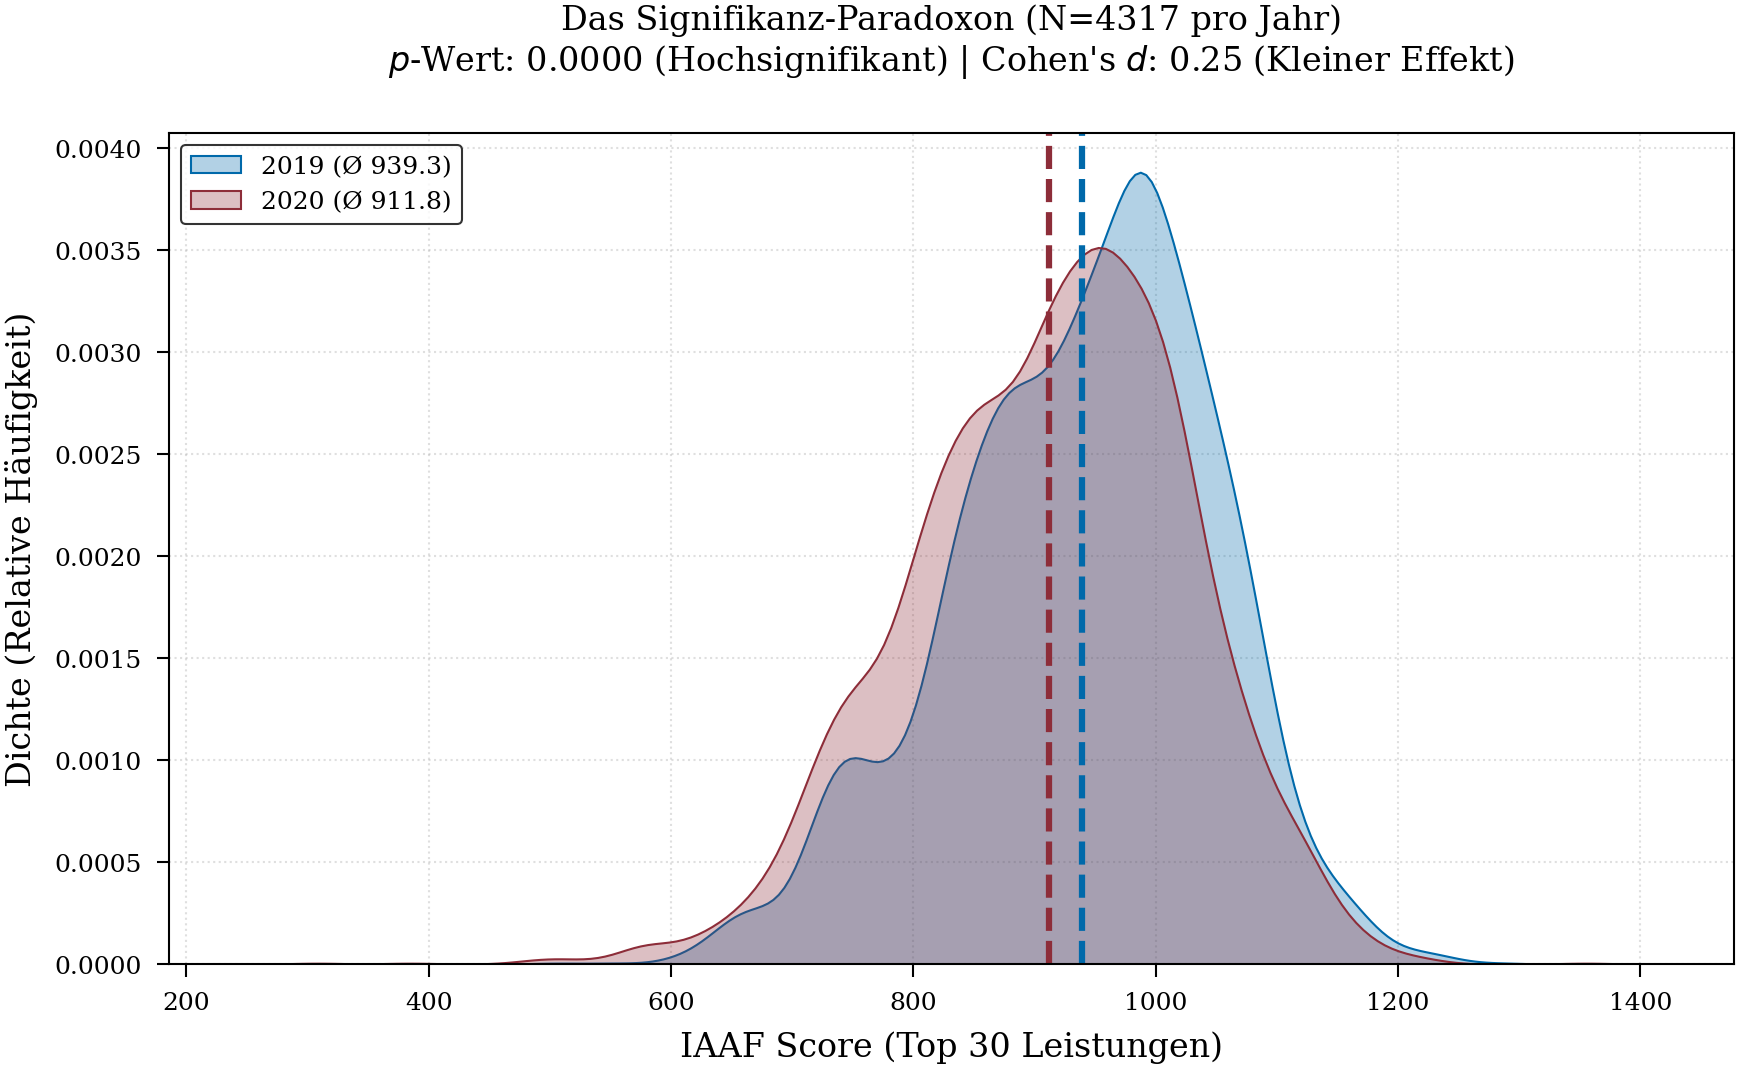

📊 Analyse abgeschlossen:
Der p-Wert von 0.0000 beweist, dass der Unterschied kein Zufall ist.
Die Effektstärke d=0.25 zeigt, dass die Verteilungen fast deckungsgleich sind.


In [6]:
import sys
import os
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

# --- 1. PROJEKT-SETUP & PFADE ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: util.py oder plotting_style.py nicht gefunden.")
    sys.exit()

# --- 2. DATEN LADEN & FILTERN ---
df = util.load_data()

# Wir vergleichen nur die Top 30 Leistungen pro Disziplin/Kategorie
# um eine saubere Datenbasis zu haben
def get_top_30_scores(df_year):
    return df_year.groupby(['disziplin', 'geschlecht', 'altersklasse'])['iaaf_score'].nlargest(30)

scores_2019 = get_top_30_scores(df[df['jahr'] == 2019])
scores_2020 = get_top_30_scores(df[df['jahr'] == 2020])

# --- 3. STATISTISCHE BERECHNUNG (P-Wert & Cohen's d) ---
t_stat, p_val = stats.ttest_ind(scores_2019, scores_2020, nan_policy='omit')

def calculate_cohen_d(x, y):
    nx, ny = len(x), len(y)
    var_x, var_y = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_sd = np.sqrt(((nx - 1) * var_x + (ny - 1) * var_y) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd

d = calculate_cohen_d(scores_2019, scores_2020)

# --- 4. VISUALISIERUNG (TÜBINGEN-STYLE) ---
# Große Darstellung (Faktor 1.8), damit man die Überlappung gut sieht
with plt.rc_context(plt.increase_figsize(1.8)):
    fig, ax = plt.subplots()

    # Dichtekurven (KDE) plotten
    sns.kdeplot(scores_2019, fill=True, label=f"2019 (Ø {scores_2019.mean():.1f})", 
                color=rgb.tue_blue, alpha=0.3, ax=ax)
    sns.kdeplot(scores_2020, fill=True, label=f"2020 (Ø {scores_2020.mean():.1f})", 
                color=rgb.tue_red, alpha=0.3, ax=ax)

    # Mittelwerte als gestrichelte Linien einzeichnen
    ax.axvline(scores_2019.mean(), color=rgb.tue_blue, linestyle='--', linewidth=1.5)
    ax.axvline(scores_2020.mean(), color=rgb.tue_red, linestyle='--', linewidth=1.5)

    # Titel mit den statistischen Ergebnissen (P-Wert und Cohen's d)
    # Nutze LaTeX für professionelle Symbole
    title = (f"Das Signifikanz-Paradoxon (N={len(scores_2019)} pro Jahr)\n"
             f"$p$-Wert: {p_val:.4f} (Hochsignifikant) | Cohen's $d$: {d:.2f} (Kleiner Effekt)")
    ax.set_title(title, pad=15)

    ax.set_xlabel("IAAF Score (Top 30 Leistungen)")
    ax.set_ylabel("Dichte (Relative Häufigkeit)")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.4)

    # Speichern des Plots
    plt.savefig("significance_paradox_kde", category="Statistik_Analyse")
    plt.show()

print(f"📊 Analyse abgeschlossen:")
print(f"Der p-Wert von {p_val:.4f} beweist, dass der Unterschied kein Zufall ist.")
print(f"Die Effektstärke d={d:.2f} zeigt, dass die Verteilungen fast deckungsgleich sind.")

✅ Projekt-Module erfolgreich geladen.


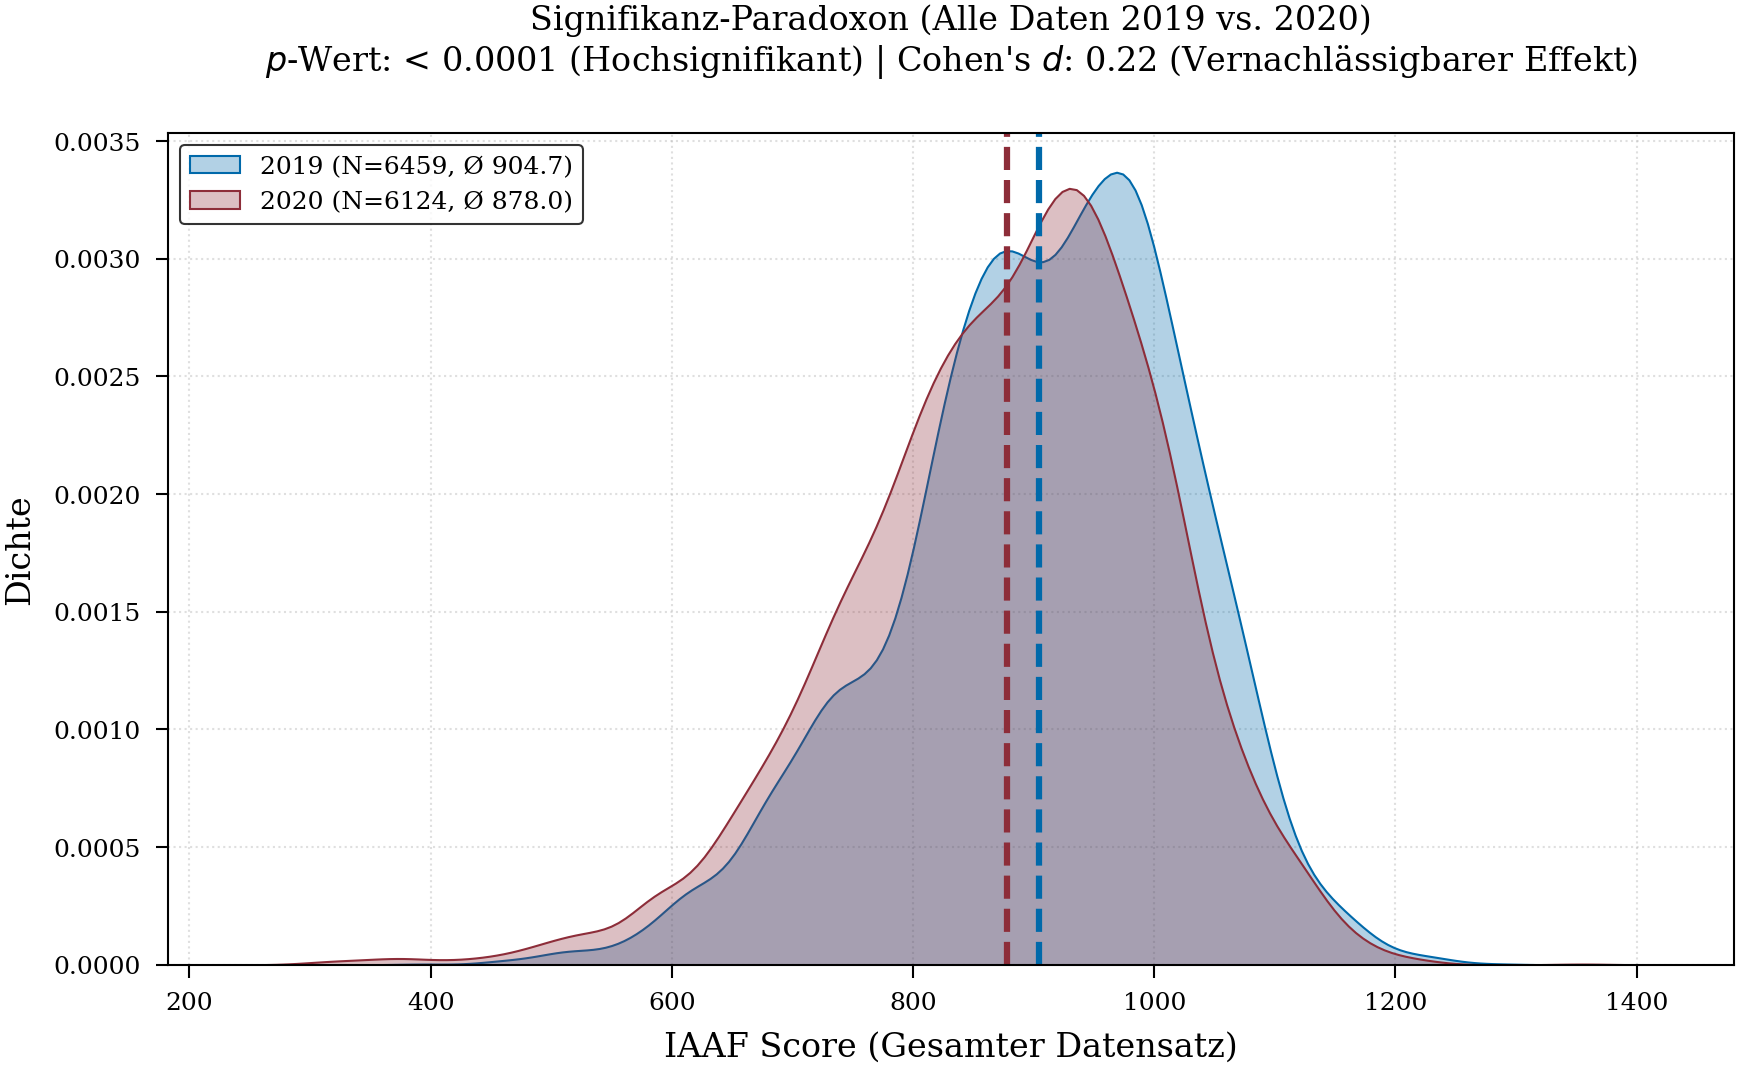

📊 Analyse mit n=12583 Datenpunkten abgeschlossen.
Effektstärke d = 0.2154


In [7]:
import sys
import os
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

# --- 1. PROJEKT-SETUP & PFADE ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: util.py oder plotting_style.py nicht gefunden.")
    sys.exit()

# --- 2. DATEN LADEN & FILTERN (Alle Daten) ---
df = util.load_data()

# Wir extrahieren ALLE Scores für 2019 und 2020
scores_2019 = df[df['jahr'] == 2019]['iaaf_score'].dropna()
scores_2020 = df[df['jahr'] == 2020]['iaaf_score'].dropna()

# --- 3. STATISTISCHE BERECHNUNG (P-Wert & Cohen's d) ---
# t-Test für unabhängige Stichproben
t_stat, p_val = stats.ttest_ind(scores_2019, scores_2020, nan_policy='omit')

# Cohen's d (Effektstärke) Berechnung
def calculate_cohen_d(x, y):
    nx, ny = len(x), len(y)
    var_x, var_y = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_sd = np.sqrt(((nx - 1) * var_x + (ny - 1) * var_y) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd

d = calculate_cohen_d(scores_2019, scores_2020)

# --- 4. VISUALISIERUNG (GROSSFORMAT) ---
# Faktor 1.8 für eine klare, große Darstellung im Notebook
with plt.rc_context(plt.increase_figsize(1.8)):
    fig, ax = plt.subplots()

    # KDE Plots für die gesamte Verteilung
    sns.kdeplot(scores_2019, fill=True, label=f"2019 (N={len(scores_2019)}, Ø {scores_2019.mean():.1f})", 
                color=rgb.tue_blue, alpha=0.3, ax=ax)
    sns.kdeplot(scores_2020, fill=True, label=f"2020 (N={len(scores_2020)}, Ø {scores_2020.mean():.1f})", 
                color=rgb.tue_red, alpha=0.3, ax=ax)

    # Mittelwerte als gestrichelte Linien
    ax.axvline(scores_2019.mean(), color=rgb.tue_blue, linestyle='--', linewidth=1.5)
    ax.axvline(scores_2020.mean(), color=rgb.tue_red, linestyle='--', linewidth=1.5)

    # Titel mit den statistischen Ergebnissen
    # Hinweis: Bei sehr kleinen p-Werten schreiben wir oft "< 0.0001"
    p_text = f"{p_val:.4f}" if p_val > 0.0001 else "< 0.0001"
    title = (f"Signifikanz-Paradoxon (Alle Daten 2019 vs. 2020)\n"
             f"$p$-Wert: {p_text} (Hochsignifikant) | Cohen's $d$: {d:.2f} (Vernachlässigbarer Effekt)")
    ax.set_title(title, pad=15)

    ax.set_xlabel("IAAF Score (Gesamter Datensatz)")
    ax.set_ylabel("Dichte")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.4)

    # Speichern des Plots im Projekt-Ordner
    plt.savefig("significance_paradox_all_data", category="Statistik_Analyse")
    plt.show()

print(f"📊 Analyse mit n={len(scores_2019) + len(scores_2020)} Datenpunkten abgeschlossen.")
print(f"Effektstärke d = {d:.4f}")

✅ Projekt-Module erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_5333/2454531933.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)


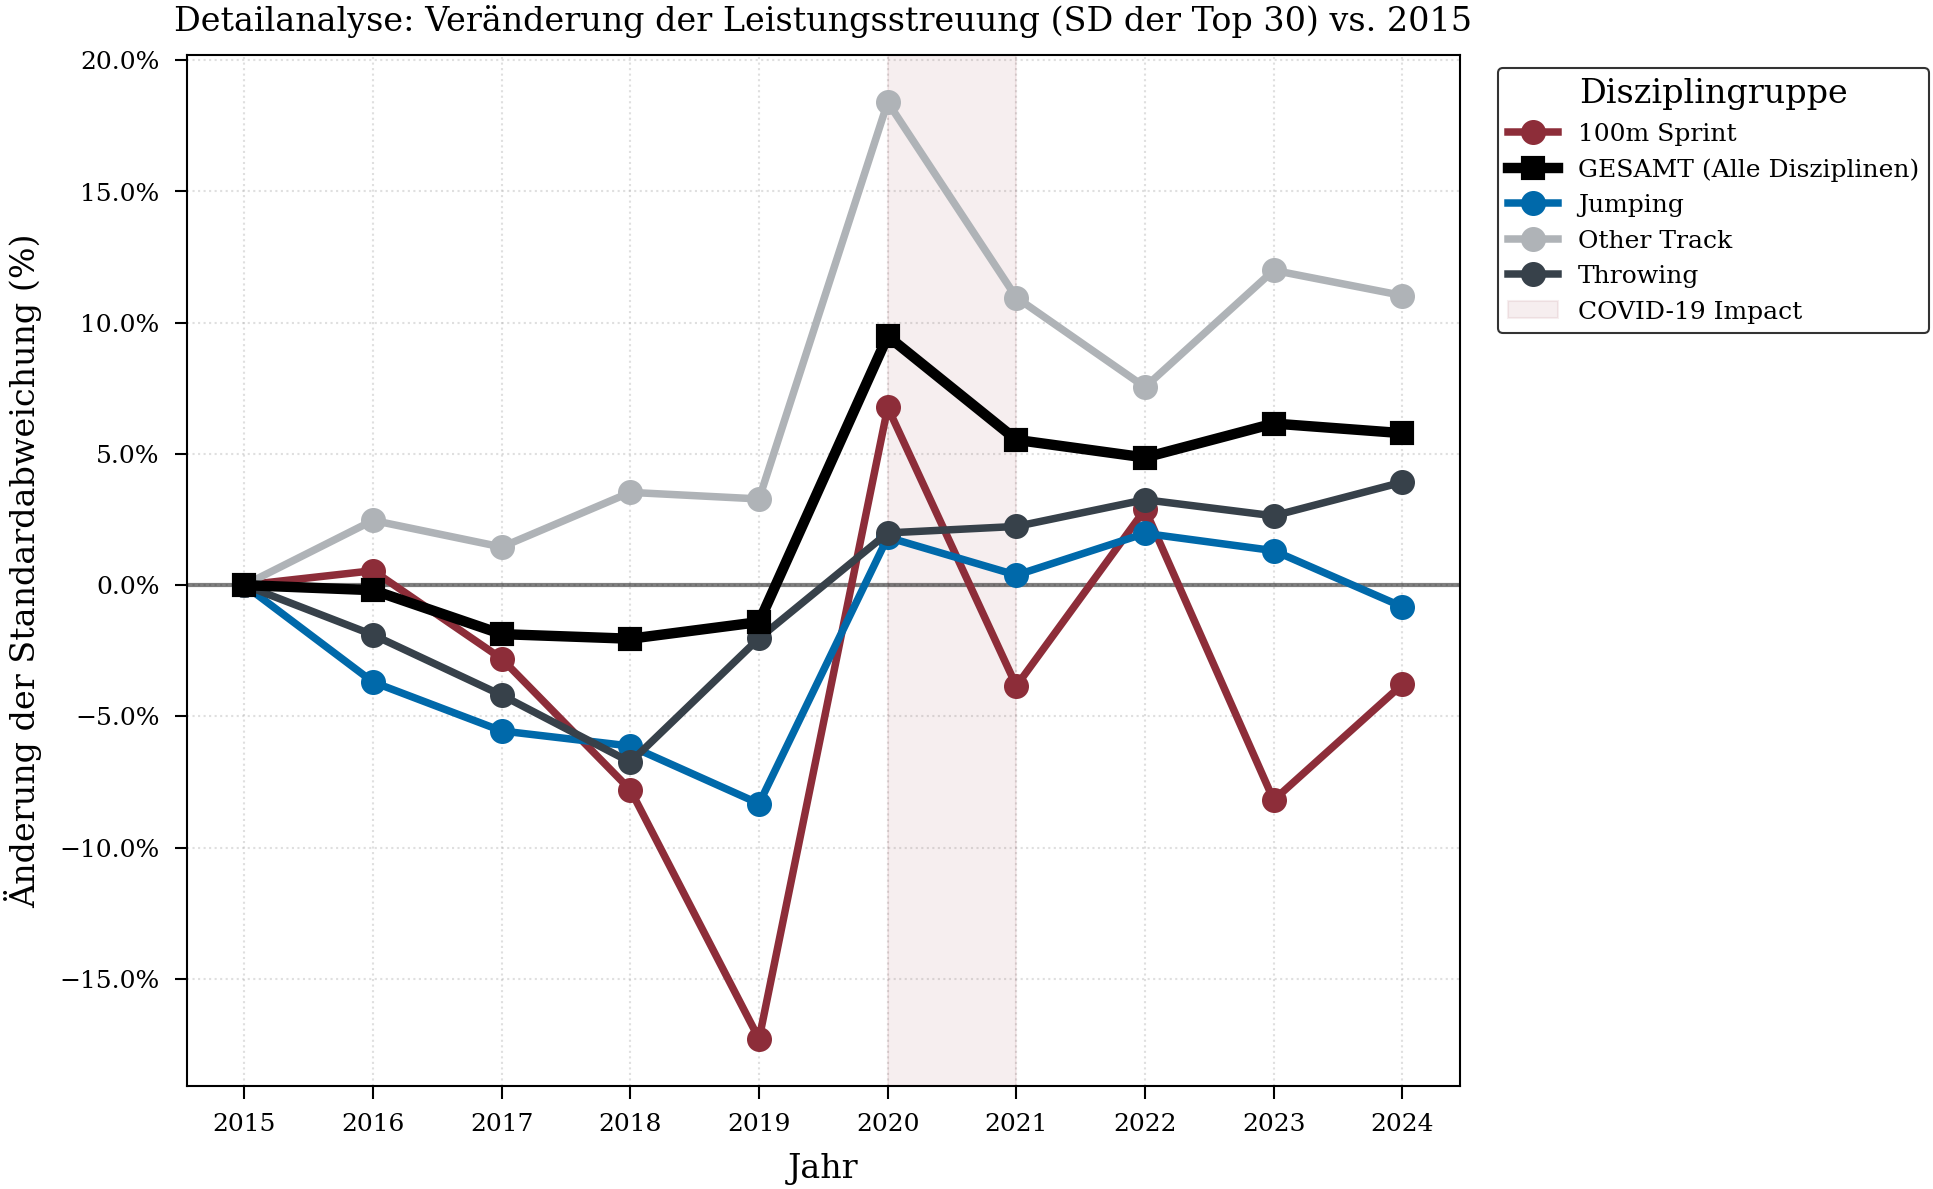

✅ Der vergrößerte Plot wurde unter 'Plots/Leistungsanalyse/' gespeichert.


In [8]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick

# --- 1. PROJEKT-SETUP & PFADE ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: util.py oder plotting_style.py nicht gefunden.")
    sys.exit()

# --- 2. DATEN LADEN & KATEGORISIEREN ---
df = util.load_data()

def categorize(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df['category'] = df['disziplin'].apply(categorize)
df_recent = df[df['jahr'] >= 2015].copy()

# --- 3. BERECHNUNG DER STANDARDABWEICHUNG (SD DER TOP 30) ---
# Wir gruppieren nach allen relevanten Merkmalen und berechnen die SD der besten 30 Scores
top_30_std = (df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin'])['iaaf_score']
              .apply(lambda x: x.nlargest(30).std())
              .reset_index(name='sd_score'))

# Aggregation auf Kategorie-Ebene (Mittelwert der SDs)
category_sd = top_30_std.groupby(['jahr', 'category'])['sd_score'].mean().reset_index()
total_sd = top_30_std.groupby(['jahr'])['sd_score'].mean().reset_index()
total_sd['category'] = 'GESAMT (Alle Disziplinen)'

final_sd_stats = pd.concat([category_sd, total_sd], ignore_index=True)

# Prozentuale Änderung berechnen (Basisjahr 2015)
def calculate_pct_change(group):
    base_val = group.loc[group['jahr'] == 2015, 'sd_score']
    if not base_val.empty and base_val.values[0] != 0:
        b = base_val.values[0]
        group['sd_rel_change_pct'] = ((group['sd_score'] - b) / b) * 100
    else:
        group['sd_rel_change_pct'] = 0
    return group

final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

# --- 4. VISUALISIERUNG (GROSSFORMAT) ---
# Hier setzen wir increase_figsize(2.0) für die größere Darstellung
with plt.rc_context(plt.increase_figsize(2.0)):
    fig, ax = plt.subplots()

    colors = {
        '100m Sprint': rgb.tue_red, 
        'Jumping': rgb.tue_blue, 
        'Throwing': rgb.tue_dark, 
        'Other Track': rgb.tue_gray, 
        'Combined Events': '#8B6914',
        'GESAMT (Alle Disziplinen)': 'black'
    }

    for cat in sorted(final_sd_stats['category'].unique()):
        cat_data = final_sd_stats[final_sd_stats['category'] == cat].sort_values('jahr')
        
        is_gesamt = 'GESAMT' in cat
        lw = 2.5 if is_gesamt else 1.8 
        z = 10 if is_gesamt else 5
        marker = 's' if is_gesamt else 'o'
        
        ax.plot(cat_data['jahr'], cat_data['sd_rel_change_pct'], 
                label=cat, color=colors.get(cat, 'gray'), 
                linewidth=lw, zorder=z, marker=marker, markersize=5)

    # Hilfslinien & Layout
    ax.axhline(0, color='black', linewidth=1.0, alpha=0.5)
    ax.axvspan(2020, 2021, color=rgb.tue_red, alpha=0.08, label='COVID-19 Impact')
    
    # X-Achse: Jedes Jahr einzeln anzeigen
    ax.xaxis.set_major_locator(mtick.MultipleLocator(1))
    
    # Y-Achse: Prozentformatierung
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    # Labels & Titel
    ax.set_title('Detailanalyse: Veränderung der Leistungsstreuung (SD der Top 30) vs. 2015')
    ax.set_ylabel('Änderung der Standardabweichung (%)')
    ax.set_xlabel('Jahr')
    
    ax.grid(True, linestyle=':', alpha=0.4)
    
    # Legende rechts außerhalb platzieren
    ax.legend(title='Disziplingruppe', loc='upper left', bbox_to_anchor=(1.02, 1))

    # Speichern des vergrößerten Plots
    plt.savefig("standard_deviation_trends_large", category="Leistungsanalyse")
    plt.show()

print("✅ Der vergrößerte Plot wurde unter 'Plots/Leistungsanalyse/' gespeichert.")

✅ Projekt-Module erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_5333/1759530263.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datum'] = pd.to_datetime(df['datum'], errors='coerce')


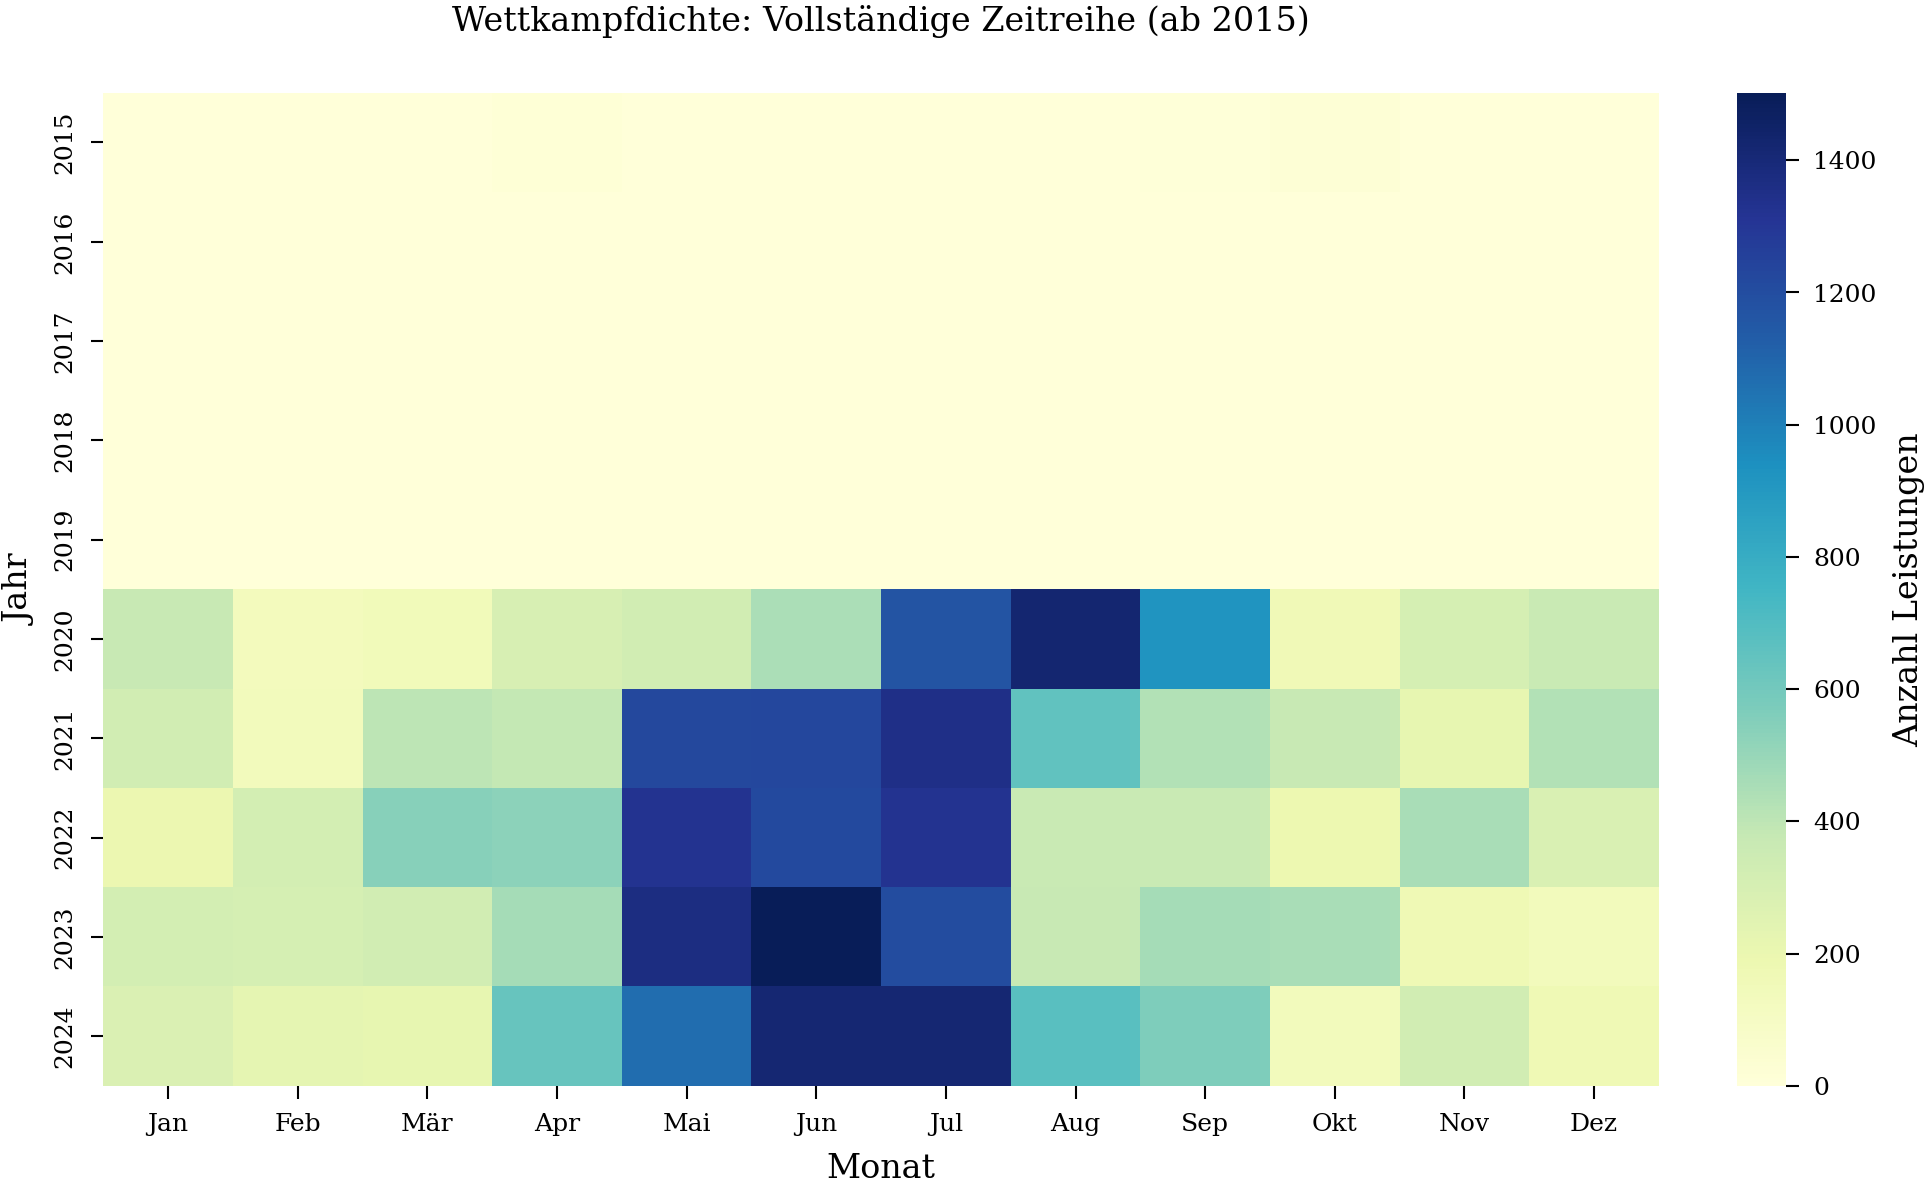

/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_5333/1759530263.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_data = df_filtered.groupby(['jahr', 'disziplin', 'geschlecht', 'altersklasse']).apply(calculate_gap_robust).reset_index(name='gap')


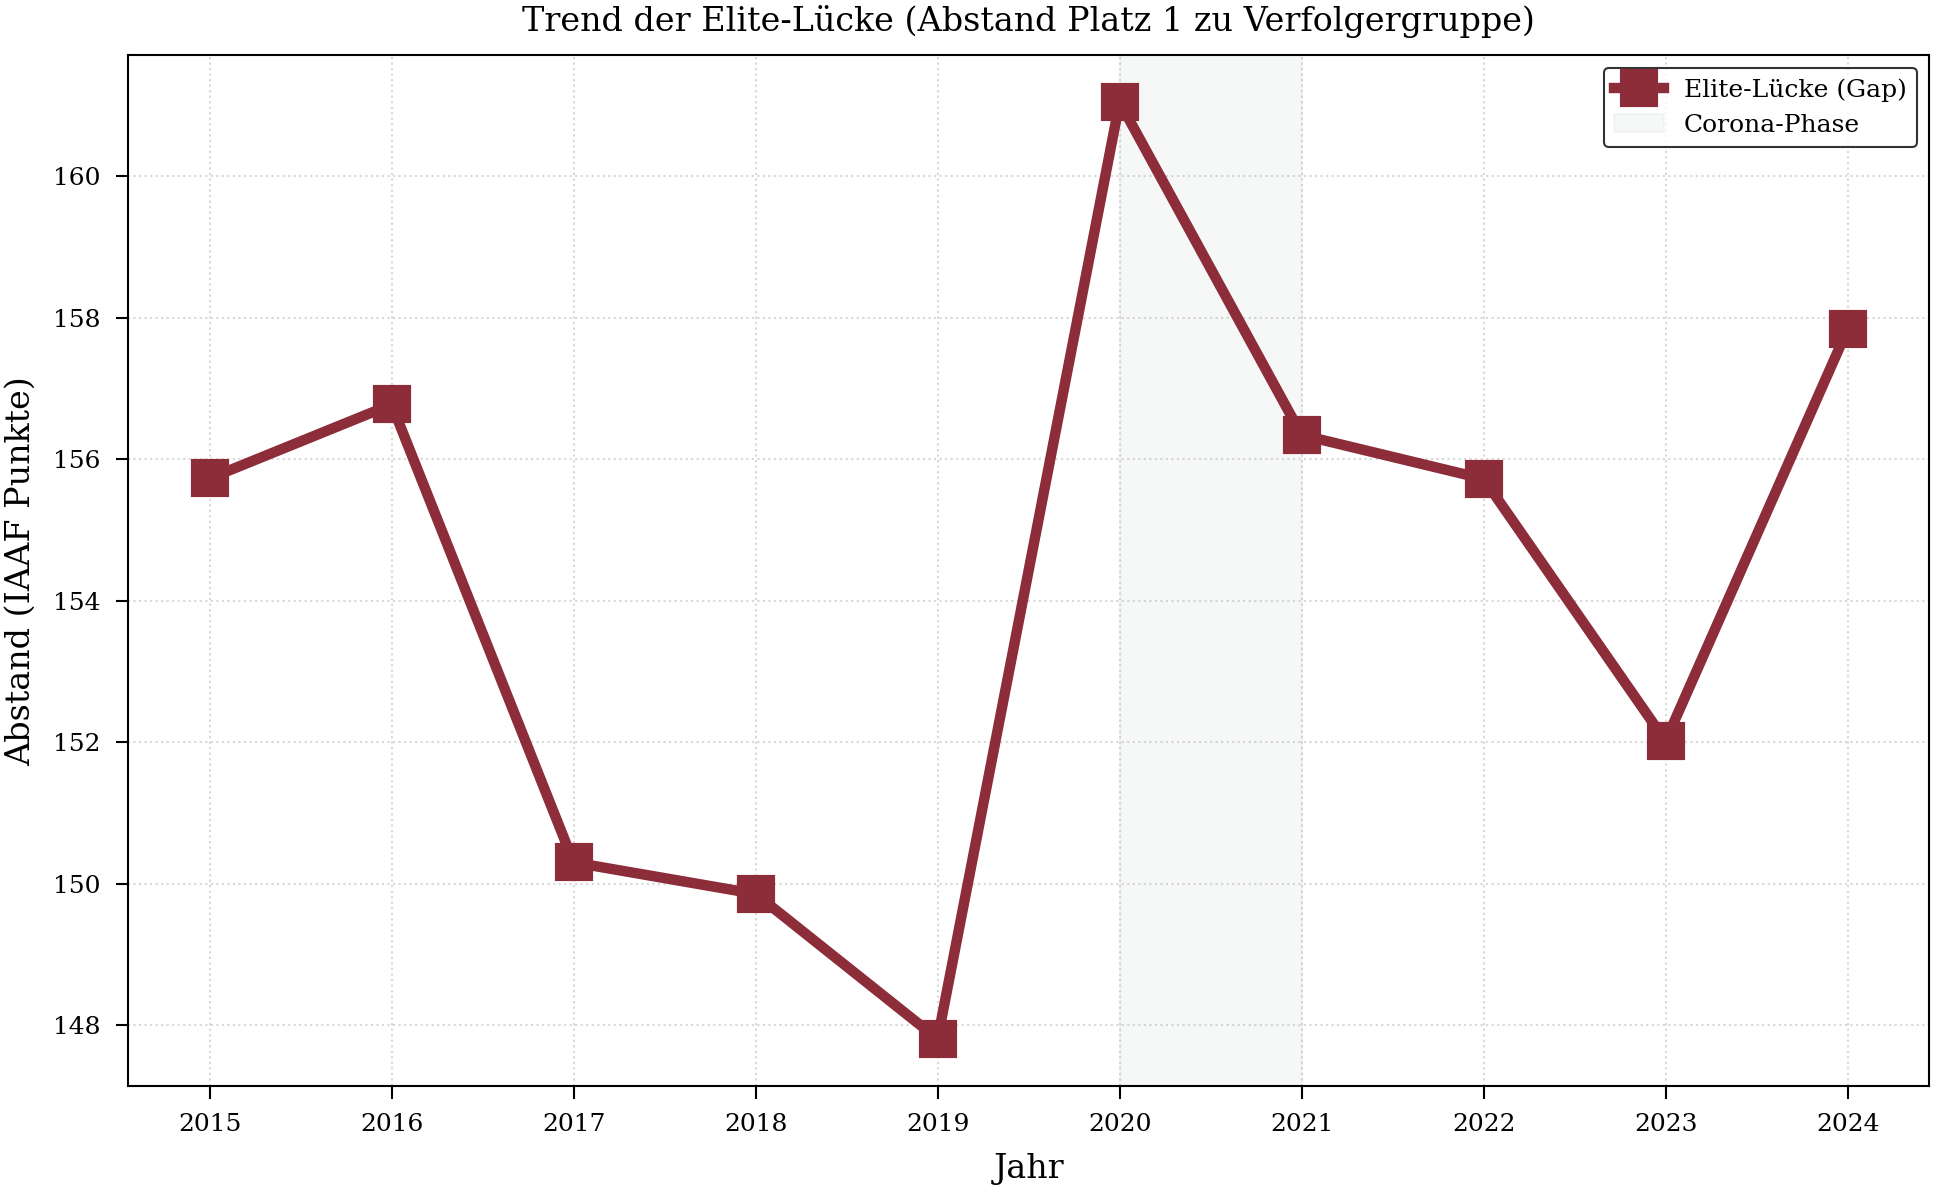


--- Daten-Check pro Jahr ---
Jahr 2015: 6212 Datensätze gefunden.
Jahr 2016: 6197 Datensätze gefunden.
Jahr 2017: 6339 Datensätze gefunden.
Jahr 2018: 6407 Datensätze gefunden.
Jahr 2019: 6459 Datensätze gefunden.
Jahr 2020: 6124 Datensätze gefunden.
Jahr 2021: 7167 Datensätze gefunden.
Jahr 2022: 7124 Datensätze gefunden.
Jahr 2023: 7103 Datensätze gefunden.
Jahr 2024: 7149 Datensätze gefunden.


In [19]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np

# --- 1. PFAD-SETUP ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: Module konnten nicht geladen werden.")
    sys.exit()

# --- 2. DATEN LADEN & VORBEREITEN ---
df = util.load_data()

# 1. Datum konvertieren
df['datum'] = pd.to_datetime(df['datum'], errors='coerce')

# 2. JAHR & MONAT sicher erstellen (Hier lag der Fehler!)
# Wir nutzen vorrangig das Datum, falls das fehlschlägt, prüfen wir, ob 'jahr' schon da ist
if 'jahr' not in df.columns:
    df['jahr'] = df['datum'].dt.year

df['monat'] = df['datum'].dt.month

# 3. Bereinigung: Wir werfen nur Zeilen weg, wo wir gar kein Jahr zuordnen können
df = df.dropna(subset=['jahr'])
df['jahr'] = df['jahr'].astype(int)

# 4. Zeitraum definieren: Fest von 2015 bis zum Maximum
min_year = 2015
max_year = int(df['jahr'].max())
if max_year < 2020: max_year = 2023 # Fallback, falls Datensatz alt ist

all_years = list(range(min_year, max_year + 1))
all_months = list(range(1, 13))

# Filter ab 2015
df_filtered = df[df['jahr'] >= min_year].copy()

# ---------------------------------------------------------
# ANALYSE 1: Heatmap (Saisonalität)
# ---------------------------------------------------------
# Jetzt ist 'monat' sicher da. Wir füllen NaN Monate mit 0 auf (für den Groupby)
df_heatmap = df_filtered.dropna(subset=['monat']).copy()
df_heatmap['monat'] = df_heatmap['monat'].astype(int)

activity = df_heatmap.groupby(['jahr', 'monat']).size().unstack(fill_value=0)

# REINDEX: Das zwingt Python, Zeilen für 2015, 2016... zu erstellen, auch wenn sie leer sind
activity = activity.reindex(index=all_years, columns=all_months, fill_value=0)

with plt.rc_context(plt.increase_figsize(2.0)):
    fig, ax = plt.subplots()
    sns.heatmap(activity, cmap="YlGnBu", ax=ax, cbar_kws={'label': 'Anzahl Leistungen'})
    
    ax.set_title('Wettkampfdichte: Vollständige Zeitreihe (ab 2015)', pad=15)
    ax.set_xlabel('Monat')
    ax.set_ylabel('Jahr')
    ax.set_xticklabels(['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
    
    plt.savefig("activity_heatmap_fixed_final", category="Senior_Analysis")
    plt.show()

# ---------------------------------------------------------
# ANALYSE 2: Elite-Gap (Berechnung auch bei wenig Daten)
# ---------------------------------------------------------
def calculate_gap_robust(group):
    n = len(group)
    if n < 1: return np.nan
    
    # TRICK: Wenn weniger als 30 Athleten da sind, nehmen wir einfach alle verfügbaren (n)
    # Das verhindert, dass das Jahr 2015 rausfliegt, nur weil wenige Daten da sind.
    k = min(n, 30)
    
    top_mean = group['iaaf_score'].nlargest(k).mean()
    best_score = group['iaaf_score'].max()
    
    return best_score - top_mean

# Berechnung pro Gruppe
gap_data = df_filtered.groupby(['jahr', 'disziplin', 'geschlecht', 'altersklasse']).apply(calculate_gap_robust).reset_index(name='gap')

# Durchschnitt pro Jahr
yearly_gap = gap_data.groupby('jahr')['gap'].mean().reset_index()

# MERGE: Wir kleben die Ergebnisse an die vollständige Jahresliste
full_years_df = pd.DataFrame({'jahr': all_years})
df_plot = pd.merge(full_years_df, yearly_gap, on='jahr', how='left')

with plt.rc_context(plt.increase_figsize(2.0)):
    fig, ax = plt.subplots()
    
    # Plotten (leere Jahre bleiben Lücken im Graphen, aber die Achse stimmt)
    ax.plot(df_plot['jahr'], df_plot['gap'], 
            marker='s', color=rgb.tue_red, linewidth=2.5, markersize=8, label='Elite-Lücke (Gap)')
    
    ax.axvspan(2020, 2021, color=rgb.tue_gray, alpha=0.1, label='Corona-Phase')
    
    # ACHSEN-FIX: Zwingt Matplotlib, jedes Jahr anzuzeigen
    ax.set_xticks(all_years)
    ax.set_xticklabels([str(y) for y in all_years])
    
    ax.set_title('Trend der Elite-Lücke (Abstand Platz 1 zu Verfolgergruppe)')
    ax.set_xlabel('Jahr')
    ax.set_ylabel('Abstand (IAAF Punkte)')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend()
    
    plt.savefig("elite_gap_fixed_final", category="Senior_Analysis")
    plt.show()

# --- DEBUGGING: ZEIGT DIR, WAS WIRKLICH IM DATENSATZ IST ---
print("\n--- Daten-Check pro Jahr ---")
counts = df['jahr'].value_counts().sort_index()
for y in all_years:
    c = counts.get(y, 0)
    print(f"Jahr {y}: {c} Datensätze gefunden.")

✅ Projekt-Module erfolgreich geladen.


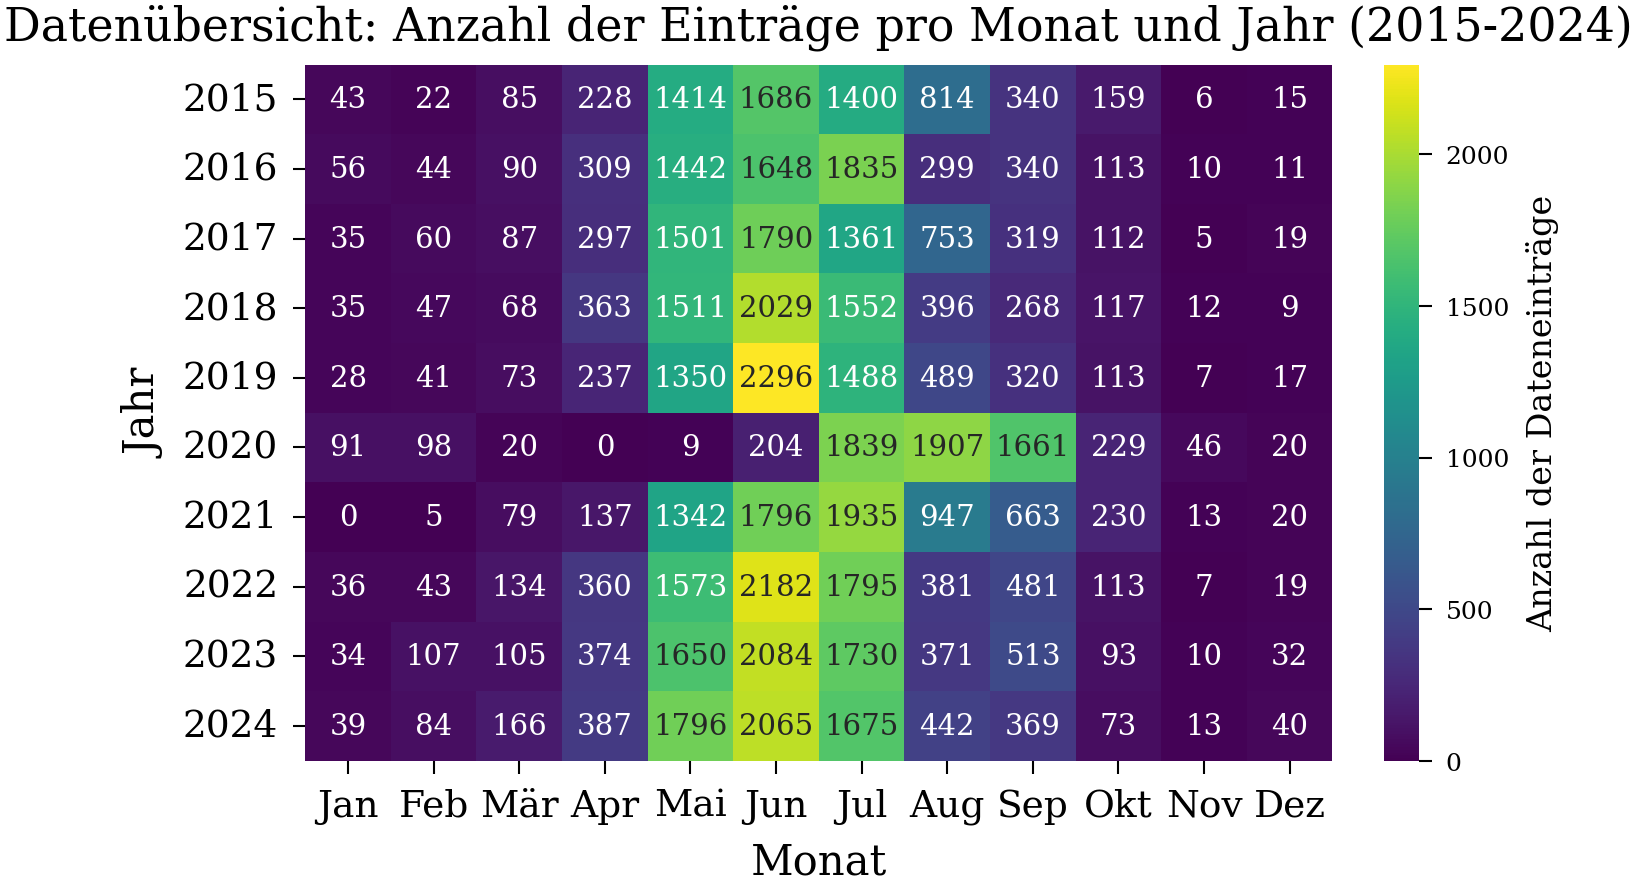

✅ Der Heatmap-Plot wurde unter 'Plots/Datenuebersicht/' gespeichert.


In [26]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick

# --- 1. PROJEKT-SETUP & PFADE ---
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: util.py oder plotting_style.py nicht gefunden.")
    sys.exit()

# --- 2. DATEN LADEN & VORBEREITEN ---
df = util.load_data()

# Datum konvertieren und Monat extrahieren
df['monat'] = df['datum'].astype(str).apply(lambda x: x.split('.')[1] if '.' in x else None)
df['monat'] = pd.to_numeric(df['monat'], errors='coerce')

# Filterung: Jahre 2015-2024 und gültige Monate (1-12)
df_heatmap = df[
    (df['jahr'] >= 2015) & 
    (df['jahr'] <= 2024) & 
    (df['monat'] >= 1) & 
    (df['monat'] <= 12)
].copy()

df_heatmap['monat'] = df_heatmap['monat'].astype(int)

# --- 3. DATEN AGGREGATION FÜR HEATMAP ---
heatmap_data = df_heatmap.groupby(['jahr', 'monat']).size().reset_index(name='anzahl')
heatmap_pivot = heatmap_data.pivot(index='jahr', columns='monat', values='anzahl')
heatmap_pivot = heatmap_pivot.fillna(0)

# --- 4. VISUALISIERUNG (HEATMAP) ---
with plt.rc_context(plt.increase_figsize(1.5)):
    fig, ax = plt.subplots()

    # Heatmap erstellen
    # annot_kws={'size': 7}: Verkleinert die Schriftgröße der Zahlen IN den Kästchen (Standard ist oft 10)
    sns.heatmap(heatmap_pivot, annot=True, fmt='g', cmap='viridis', ax=ax, 
                cbar_kws={'label': 'Anzahl der Dateneinträge'},
                annot_kws={'size': 7}) 

    # Labels & Titel (Schriftgrößen angepasst)
    ax.set_title('Datenübersicht: Anzahl der Einträge pro Monat und Jahr (2015-2024)', fontsize=11)
    ax.set_ylabel('Jahr', fontsize=10)
    ax.set_xlabel('Monat', fontsize=10)

    # X-Achse: Monatsnamen
    german_months = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
    ax.set_xticklabels(german_months)
    
    # Y-Achse: Labels waagerecht
    plt.yticks(rotation=0)

    # Achsen-Ticks global verkleinern (für x und y)
    ax.tick_params(axis='both', labelsize=9)

    # Speichern
    plt.savefig("heatmap_entries_per_month", category="Datenuebersicht")
    plt.show()

print("✅ Der Heatmap-Plot wurde unter 'Plots/Datenuebersicht/' gespeichert.")

In [27]:
import sys
import pandas as pd

# --- 1. SETUP ---
# (Dein Pfad-Setup wie gewohnt)
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

try:
    import util
except ImportError:
    print("❌ Fehler: util.py nicht gefunden.")
    sys.exit()

# --- 2. DATEN LADEN & FILTERN ---
df = util.load_data()

# Filter auf die relevanten Jahre
df_filtered = df[(df['jahr'] >= 2015) & (df['jahr'] <= 2024)].copy()

# Definitionsgruppen für "Top N": 
# Ein Athlet gehört zu den Top N seiner spezifischen Gruppe (Jahr, Disziplin, Geschlecht, Altersklasse)
group_cols = ['jahr', 'disziplin', 'geschlecht', 'altersklasse']

# --- 3. BERECHNUNG DER ANZAHLEN ---

def count_top_n_per_year(dataframe, n):
    """
    Filtert den DataFrame auf die Top N Einträge pro Gruppe 
    und gibt die Anzahl der verbleibenden Einträge pro Jahr zurück.
    """
    # Gruppieren und die Top N basierend auf 'iaaf_score' behalten
    top_n_df = dataframe.groupby(group_cols, group_keys=False).apply(lambda x: x.nlargest(n, 'iaaf_score'))
    
    # Zählen, wie viele Einträge pro Jahr übrig bleiben
    return top_n_df.groupby('jahr').size()

print("Berechne Statistiken (das kann einen Moment dauern)...")

# Berechnung durchführen
count_all = df_filtered.groupby('jahr').size()
count_top50 = count_top_n_per_year(df_filtered, 50)
count_top30 = count_top_n_per_year(df_filtered, 30)

# --- 4. ERGEBNIS ZUSAMMENFÜHREN & ANZEIGEN ---
results = pd.DataFrame({
    'Gesamt': count_all,
    'Top 50': count_top50,
    'Top 30': count_top30
})

# Tabelle formatieren und anzeigen
print("\n--- Anzahl der Dateneinträge pro Jahr (2015-2024) ---")
print(results)

# Optional: Als Markdown oder CSV speichern/ausgeben
# print(results.to_markdown())

Berechne Statistiken (das kann einen Moment dauern)...


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_5333/673904868.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_n_df = dataframe.groupby(group_cols, group_keys=False).apply(lambda x: x.nlargest(n, 'iaaf_score'))



--- Anzahl der Dateneinträge pro Jahr (2015-2024) ---
      Gesamt  Top 50  Top 30
jahr                        
2015    6212    6185    4268
2016    6197    6153    4264
2017    6339    6269    4290
2018    6407    6368    4317
2019    6459    6417    4317
2020    6124    6084    4261
2021    7167    7089    4347
2022    7124    7037    4346
2023    7103    7047    4342
2024    7149    7103    4403


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_5333/673904868.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_n_df = dataframe.groupby(group_cols, group_keys=False).apply(lambda x: x.nlargest(n, 'iaaf_score'))


<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_963/1944850022.py:48: SyntaxWarning: invalid escape sequence '\p'
  label=f'1 Std. Abw. ($\pm {std_score:.1f}$)')
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_963/1944850022.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top30_men = df_men.groupby(['jahr', 'disziplin'], group_keys=False).apply(get_top_30)


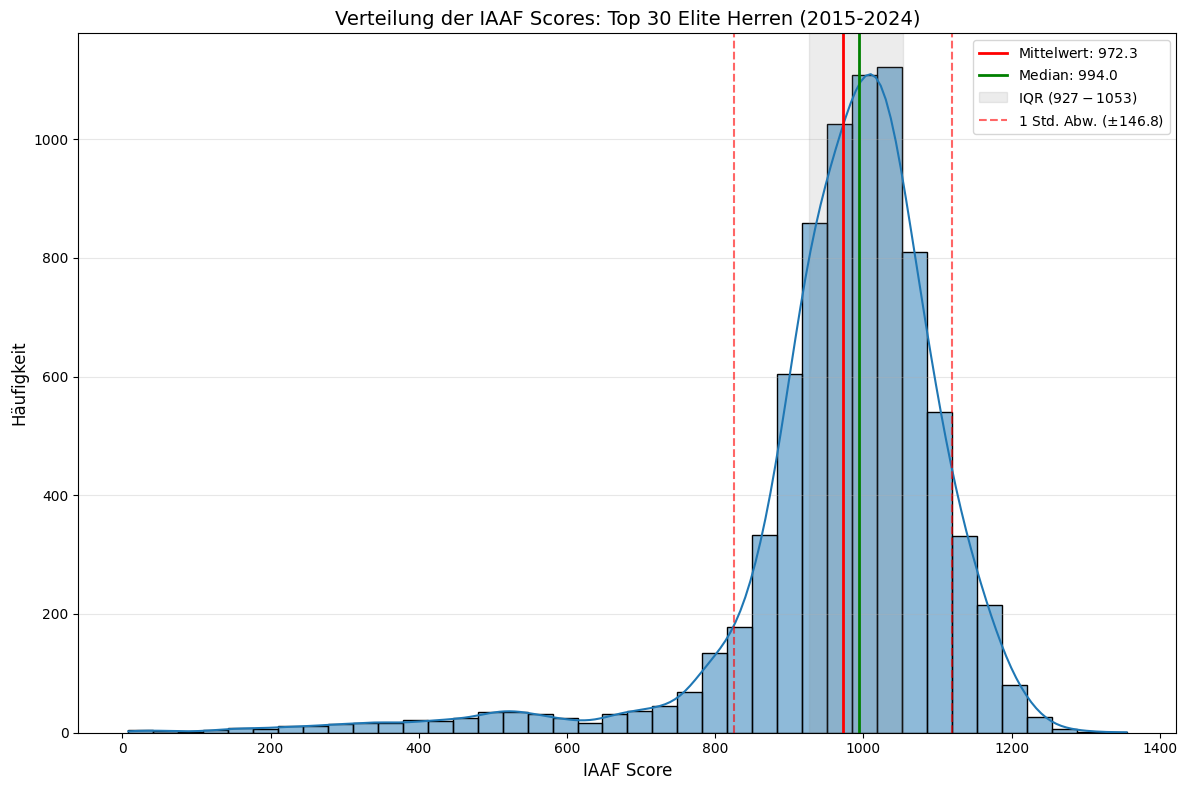

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Daten laden
df = pd.read_csv('final_Data_iaaf_scores_neu.csv', delimiter=';')

# 2. Filtern: Herren (M), Altersklasse 'Männer', Jahre 2015-2024
df_men = df[
    (df['geschlecht'] == 'M') & 
    (df['altersklasse'] == 'Maenner') & 
    (df['jahr'] >= 2015) & 
    (df['jahr'] <= 2024)
].copy()

# 3. Top 30 Filterung
def get_top_30(group):
    return group.nlargest(30, 'iaaf_score')

df_top30_men = df_men.groupby(['jahr', 'disziplin'], group_keys=False).apply(get_top_30)

# 4. Plotten der Verteilung
plt.figure(figsize=(12, 8))

# Histogramm mit Dichtekurve (KDE)
sns.histplot(df_top30_men['iaaf_score'], kde=True, bins=40, 
             color='#1f77b4', edgecolor='black', alpha=0.5)

# Statistiken berechnen
mean_score = df_top30_men['iaaf_score'].mean()
std_score = df_top30_men['iaaf_score'].std()
median_score = df_top30_men['iaaf_score'].median()
q1 = df_top30_men['iaaf_score'].quantile(0.25)
q3 = df_top30_men['iaaf_score'].quantile(0.75)

# Mittelwert und Median einzeichnen
plt.axvline(mean_score, color='red', linestyle='-', linewidth=2, 
            label=f'Mittelwert: ${mean_score:.1f}$')
plt.axvline(median_score, color='green', linestyle='-', linewidth=2, 
            label=f'Median: ${median_score:.1f}$')

# IQR (Interquartilsabstand) schattiert darstellen
plt.axvspan(q1, q3, color='gray', alpha=0.15, label=f'IQR (${q1:.0f} - {q3:.0f}$)')

# Standardabweichung (STD) einzeichnen
# Wir zeichnen gestrichelte Linien bei Mittelwert - 1 STD und Mittelwert + 1 STD
plt.axvline(mean_score - std_score, color='red', linestyle='--', alpha=0.6, 
            label=f'1 Std. Abw. ($\pm {std_score:.1f}$)')
plt.axvline(mean_score + std_score, color='red', linestyle='--', alpha=0.6)

# Titel und Achsen
plt.title('Verteilung der IAAF Scores: Top 30 Elite Herren (2015-2024)', fontsize=14)
plt.xlabel('IAAF Score', fontsize=12)
plt.ylabel('Häufigkeit', fontsize=12)

# Legende
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_963/1956169673.py:57: SyntaxWarning: invalid escape sequence '\p'
  label=f'1 Std. Abw. ($\pm {std_v:.1f}$)')
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_963/1956169673.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top30_men = df_men.groupby(['jahr', 'disziplin'], group_keys=False).apply(get_top_30)


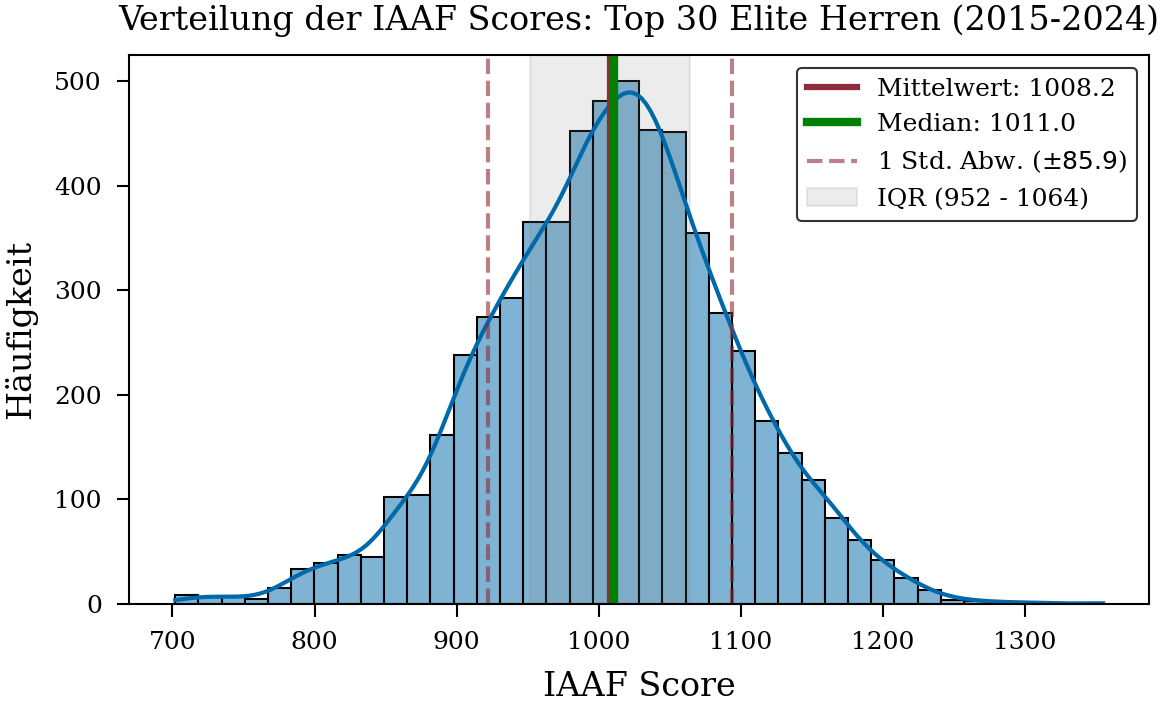

In [9]:
import sys
import os
import pandas as pd
import seaborn as sns
import numpy as np

# 1. Projektpfad einrichten (angepasst an die Readme-Struktur)
# Falls du dich in einem Unterordner wie 'erik/' befindest, nutze "../"
sys.path.append(os.path.abspath("..")) 

import util
import plotting.plotting_style as plt  # Nutzt das Uni-Tübingen Design
from plotting.plotting_style import rgb

# 2. Daten über util.py laden
# util.load_data() erledigt bereits die Konvertierung von Einheiten
df = util.load_data() 

# 3. Filtern: Elite Herren (2015-2024)
# Wir fügen einen Schwellenwert von 700 ein, um die fehlerhaften "200er" Scores zu entfernen
df_men = df[
    (df['geschlecht'] == 'M') & 
    (df['altersklasse'] == 'Maenner') & 
    (df['jahr'] >= 2015) & 
    (df['jahr'] <= 2024) &
    (df['iaaf_score'] > 700) 
].copy()

# 4. Top 30 Filterung pro Jahr und Disziplin
def get_top_30(group):
    return group.nlargest(30, 'iaaf_score')

df_top30_men = df_men.groupby(['jahr', 'disziplin'], group_keys=False).apply(get_top_30)

# 5. Statistiken berechnen
scores = df_top30_men['iaaf_score']
mean_v = scores.mean()
std_v = scores.std()
median_v = scores.median()
q1, q3 = scores.quantile([0.25, 0.75])

# 6. Plotting mit dem Projekt-Style
# Wir nutzen rc_context für eine optimale Größe im Report
with plt.rc_context(plt.increase_figsize(1.2)):
    # Histogramm
    sns.histplot(scores, kde=True, bins=40, 
                 color=rgb.tue_blue, edgecolor='black', alpha=0.5)

    # Vertikale Linien für Maße
    plt.axvline(mean_v, color=rgb.tue_red, linestyle='-', linewidth=1.5, 
                label=f'Mittelwert: {mean_v:.1f}')
    plt.axvline(median_v, color='green', linestyle='-', linewidth=2, 
                label=f'Median: {median_v:.1f}')
    
    # Standardabweichung (Bereich um Mittelwert)
    plt.axvline(mean_v - std_v, color=rgb.tue_red, linestyle='--', alpha=0.6, 
                label=f'1 Std. Abw. ($\pm {std_v:.1f}$)')
    plt.axvline(mean_v + std_v, color=rgb.tue_red, linestyle='--', alpha=0.6)

    # IQR schattieren
    plt.axvspan(q1, q3, color='gray', alpha=0.15, label=f'IQR ({q1:.0f} - {q3:.0f})')

    # Beschriftung (Nutzt automatisch die Schrifteinstellungen aus plotting_style)
    plt.title('Verteilung der IAAF Scores: Top 30 Elite Herren (2015-2024)')
    plt.xlabel('IAAF Score')
    plt.ylabel('Häufigkeit')
    plt.legend(loc='upper right')

   
    
    plt.show()

✅ Projekt-Module erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_963/311028501.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)


✅ Analyse abgeschlossen. Plot in 'Plots/Corona_Analyse/' gespeichert.


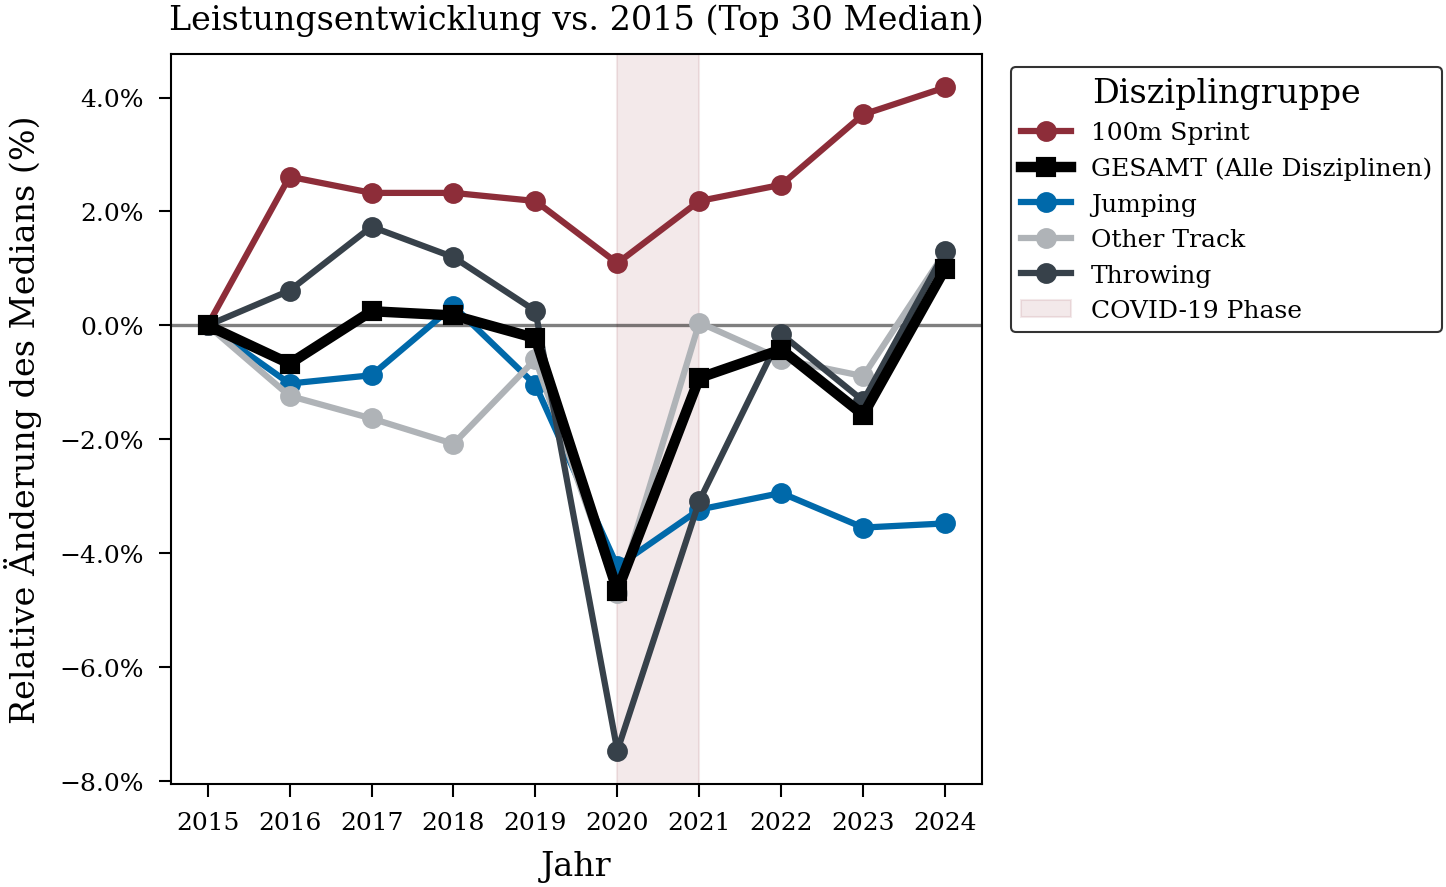

In [7]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick
import numpy as np

# --- 1. PROJEKT-SETUP & PFADE (Laut Readme) ---
# Falls das Skript in einem Unterordner liegt, Pfad zum Root hinzufügen
sys.path.append(os.path.abspath("..")) 

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: util.py oder plotting_style.py nicht gefunden. Pfad prüfen!")
    sys.exit()

# --- 2. DATEN LADEN & KATEGORISIEREN ---
# Wir laden die Daten über das util-Modul
df = util.load_data()

# Vor-Filterung: Nur Männer, relevante Jahre und SCHUTZ vor 200er-Scores (> 700 Punkte)
df_recent = df[
    (df['geschlecht'] == 'M') & 
    (df['altersklasse'] == 'Maenner') & 
    (df['jahr'] >= 2015) & 
    (df['jahr'] <= 2024) &
    (df['iaaf_score'] > 700)
].copy()

def categorize(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df_recent['category'] = df_recent['disziplin'].apply(categorize)

# --- 3. TOP 30 BERECHNUNG (UMSTELLUNG AUF MEDIAN) ---

# Hier berechnen wir nun den MEDIAN der Top 30 pro Wettbewerb
top_30_stats = (df_recent.groupby(['jahr', 'category', 'disziplin'])['iaaf_score']
                .apply(lambda x: x.nlargest(30).median()) # <--- MEDIAN statt MEAN
                .reset_index(name='iaaf_score_median'))

# Aggregation auf Kategorie-Ebene (Median der Mediane)
category_stats = top_30_stats.groupby(['jahr', 'category'])['iaaf_score_median'].median().reset_index()
total_stats = top_30_stats.groupby(['jahr'])['iaaf_score_median'].median().reset_index()
total_stats['category'] = 'GESAMT (Alle Disziplinen)'

final_stats = pd.concat([category_stats, total_stats], ignore_index=True)

# Relative Änderung basierend auf dem Median von 2015 berechnen
def calculate_pct_change(group):
    base_val = group.loc[group['jahr'] == 2015, 'iaaf_score_median']
    if not base_val.empty:
        b = base_val.values[0]
        group['rel_change_pct'] = ((group['iaaf_score_median'] - b) / b) * 100
    else:
        group['rel_change_pct'] = 0
    return group

final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

# --- 4. VISUALISIERUNG (TUEPLOTS DESIGN) ---
colors = {
    '100m Sprint': rgb.tue_red, 
    'Jumping': rgb.tue_blue, 
    'Throwing': rgb.tue_dark,
    'Other Track': rgb.tue_gray, 
    'Combined Events': '#8B6914', 
    'GESAMT (Alle Disziplinen)': 'black'
}

# Nutzung der empfohlenen Skalierung aus der Readme
with plt.rc_context(plt.increase_figsize(1.5)):
    fig, ax = plt.subplots()
    
    for cat in sorted(final_stats['category'].unique()):
        cat_data = final_stats[final_stats['category'] == cat].sort_values('jahr')
        
        is_gesamt = 'GESAMT' in cat
        lw = 2.5 if is_gesamt else 1.5
        z = 10 if is_gesamt else 5
        marker = 's' if is_gesamt else 'o'
        
        ax.plot(cat_data['jahr'], cat_data['rel_change_pct'], 
                label=cat, color=colors.get(cat, 'gray'), 
                linewidth=lw, zorder=z, marker=marker, markersize=4)

    # Nulllinie und COVID-Markierung
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.axvspan(2020, 2021, color=rgb.tue_red, alpha=0.1, label='COVID-19 Phase')
    
    # Formatierung
    ax.xaxis.set_major_locator(mtick.MultipleLocator(1))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    ax.set_title('Leistungsentwicklung vs. 2015 (Top 30 Median)')
    ax.set_ylabel('Relative Änderung des Medians (%)')
    ax.set_xlabel('Jahr')
    
    # Legende laut Readme positionieren
    ax.legend(title='Disziplingruppe', loc='upper left', bbox_to_anchor=(1.02, 1))
    
   
print("✅ Analyse abgeschlossen. Plot in 'Plots/Corona_Analyse/' gespeichert.")

✅ util.py und plotting_style.py aus dem Repository geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_963/3841817769.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)


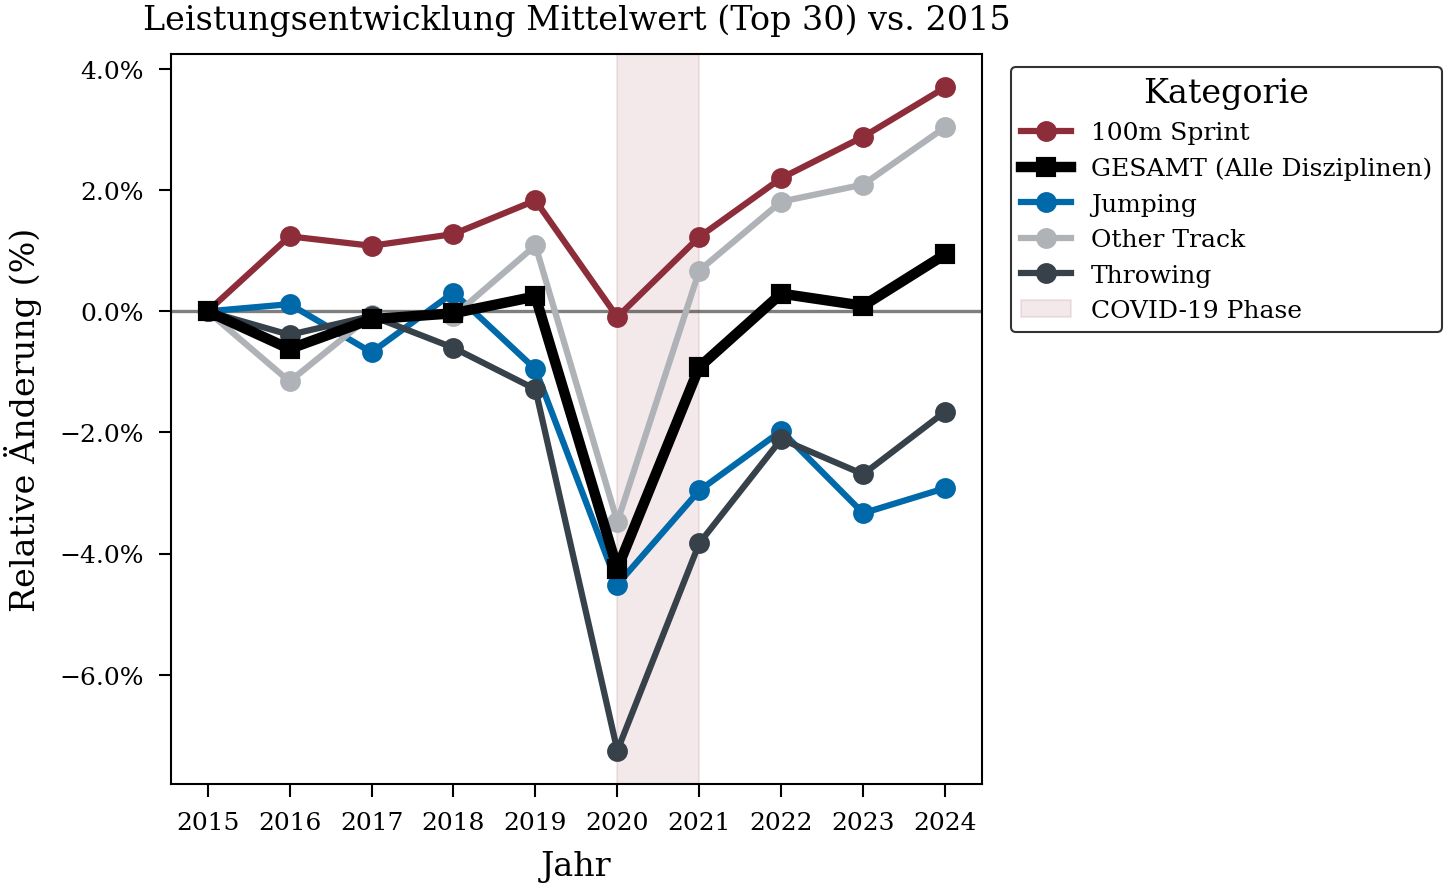

In [8]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick
import numpy as np

# --- 1. PROJEKT-SETUP (Zentrales Laden laut Readme) ---
# Wir gehen davon aus, dass dieses Skript in einem Unterordner (z.B. erik/) liegt
sys.path.append(os.path.abspath("..")) 

try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ util.py und plotting_style.py aus dem Repository geladen.")
except ImportError:
    print("❌ Fehler: util.py nicht gefunden. Prüfe, ob sys.path auf das Root-Verzeichnis zeigt.")
    sys.exit()

# --- 2. DATEN LADEN ÜBER UTIL ---
# util.load_data() findet die CSV im Ordner data_csv/ automatisch
df = util.load_data()

# Vor-Filterung: Elite Männer & Schutz vor den 200er-Ausreißern
df_recent = df[
    (df['geschlecht'] == 'M') & 
    (df['altersklasse'] == 'Maenner') & 
    (df['jahr'] >= 2015) & 
    (df['jahr'] <= 2024) &
    (df['iaaf_score'] > 700) # Bereinigung der Datenfehler
].copy()

# Kategorisierung
def categorize(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df_recent['category'] = df_recent['disziplin'].apply(categorize)

# --- 3. BERECHNUNG: MITTELWERT DER TOP 30 ---
# 1. Mittelwert pro Disziplin (Top 30)
top_30_stats = (df_recent.groupby(['jahr', 'category', 'disziplin'])['iaaf_score']
                .apply(lambda x: x.nlargest(30).mean())
                .reset_index(name='iaaf_score_mean'))

# 2. Mittelwert pro Kategorie
category_stats = top_30_stats.groupby(['jahr', 'category'])['iaaf_score_mean'].mean().reset_index()

# 3. Gesamtdurchschnitt über alle Disziplinen
total_stats = top_30_stats.groupby(['jahr'])['iaaf_score_mean'].mean().reset_index()
total_stats['category'] = 'GESAMT (Alle Disziplinen)'

final_stats = pd.concat([category_stats, total_stats], ignore_index=True)

# 4. Relative Änderung zu 2015 berechnen
def calculate_pct_change(group):
    base_val = group.loc[group['jahr'] == 2015, 'iaaf_score_mean']
    if not base_val.empty:
        b = base_val.values[0]
        group['rel_change_pct'] = ((group['iaaf_score_mean'] - b) / b) * 100
    else:
        group['rel_change_pct'] = 0
    return group

final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

# --- 4. VISUALISIERUNG (Uni Tübingen Design) ---
colors = {
    '100m Sprint': rgb.tue_red, 
    'Jumping': rgb.tue_blue, 
    'Throwing': rgb.tue_dark,
    'Other Track': rgb.tue_gray, 
    'Combined Events': '#8B6914', 
    'GESAMT (Alle Disziplinen)': 'black'
}

# Image of a line graph comparing different groups of athletic disciplines over time

with plt.rc_context(plt.increase_figsize(1.5)):
    fig, ax = plt.subplots()
    
    for cat in sorted(final_stats['category'].unique()):
        cat_data = final_stats[final_stats['category'] == cat].sort_values('jahr')
        
        is_gesamt = 'GESAMT' in cat
        lw = 2.5 if is_gesamt else 1.5
        ax.plot(cat_data['jahr'], cat_data['rel_change_pct'], 
                label=cat, color=colors.get(cat, 'gray'), 
                linewidth=lw, zorder=10 if is_gesamt else 5, 
                marker='s' if is_gesamt else 'o', markersize=4)

    # Styling & Corona-Highlight
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.axvspan(2020, 2021, color=rgb.tue_red, alpha=0.1, label='COVID-19 Phase')
    
    ax.xaxis.set_major_locator(mtick.MultipleLocator(1))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    ax.set_title('Leistungsentwicklung Mittelwert (Top 30) vs. 2015')
    ax.set_ylabel('Relative Änderung (%)')
    ax.set_xlabel('Jahr')
    
    # Legende außerhalb platzieren
    ax.legend(title='Kategorie', loc='upper left', bbox_to_anchor=(1.02, 1))
    
    # Automatisches Speichern im Plots-Ordner laut Readme
    plt.savefig("leistungsentwicklung_mean_final", category="Corona_Analyse")
    plt.show()